<a href="https://colab.research.google.com/github/DrJHM/2026-Capstone-Project---JHM/blob/main/Spring_2026_Capstone_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Spring 2026 - DATA 801 Capstone Project | Howard University | Applied Data Science and Analytics
**Joycelyn Hughes-Moulden** | Spring 2026

---

## Research Context

This notebook constitutes the **statistical foundation** of the HBCU Student Success Platform Study capstone project. HBCU Student Success Platform Study advances a central argument: Historically Black Colleges and Universities (HBCUs) are currently underserved by commercially dominant student success platforms designed around the demographic and institutional profiles of Predominantly White Institutions (PWIs). A purpose-built HBCU student success platform is not merely preferable; it is structurally necessary.

## Primary Research Questions

1. Do student success platforms designed for PWIs help HBCUs close gaps in retention and graduation rates?

2. If not, what type of student success platform would be more effective for HBCUs?

## Deeper Inquiry

a.) Which institution-level academic and student support indicators correlate most strongly with **first-year retention** and **six-year graduation rates** at HBCUs?

b.) Do HBCUs and PWIs differ significantly on key student success outcomes — and if so, does the pattern suggest that platform adoption alone cannot close the gap?

c.) What structural data quality issues (multicollinearity, imbalance, missing data) must be diagnosed and remediated before building predictive ML models?

## Dataset

A curated 51-institution comparative dataset (26 HBCUs + 25 PWIs) drawn from IPEDS, NACUBO, College Scorecard, EAB/Institutional Websites, and the Hope Center HBCU Basic Needs Survey. Key variable groups include:
- **Outcome variables**: 6-year graduation rate, first-year retention rate
- **Structural variables**: enrollment, endowment per student, sector (public/private)
- **Student-need indicators**: % Pell recipients, % first-generation students, % financial shock, % housing insecurity
- **Platform adoption**: Navigate (EAB), Starfish, Workday Student
- **Advising infrastructure**: proactive advising model, early alert system, degree audit tool
- **Longitudinal retention trends**: AY 2016-17 through 2023-24

## Assignment Objectives

This notebook fulfills:
1. **Exploratory Data Analysis (EDA)** — descriptive statistics, visual distributions, and correlation analysis
2. **Formal Hypothesis Testing** — T-test and Pearson correlation with stated H₀/H₁ and p-value interpretation
3. **Pre-ML Diagnosis & Remediation** — multicollinearity (VIF), class imbalance, missing values, and outlier treatment
4. **Code Quality** — clean, commented, reproducible Python with narrative Markdown cells


## Environment Setup

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS & GLOBAL SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings('ignore')

# ── Aesthetics ────────────────────────────────────────────────────────────────
HBCU_COLOR   = '#1A5276'   # deep navy  — primary HBCU brand color
PWI_COLOR    = '#D4AC0D'   # gold       — contrast color for PWIs
ACCENT_COLOR = '#922B21'   # crimson    — alerts / emphasis

sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams['figure.dpi']    = 120
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("✓ All libraries loaded successfully.")
print(f"  pandas   {pd.__version__}")
print(f"  numpy    {np.__version__}")
print(f"  seaborn  {sns.__version__}")


✓ All libraries loaded successfully.
  pandas   2.2.2
  numpy    2.0.2
  seaborn  0.13.2


## Section 0 — Data Loading & Initial Inspection

The raw CSV is loaded and given a first-pass inspection before any cleaning occurs.
Column names are trimmed of leading/trailing whitespace, which is a common artifact
in IPEDS-derived spreadsheets.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD RAW DATA
# ─────────────────────────────────────────────────────────────────────────────

# Update DATA_PATH to the location of the CSV file in your environment.
DATA_PATH = 'Data_for_Revised_Capstone_Enhanced.csv'

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# Strip whitespace and BOM artifacts from column names
df_raw.columns = (df_raw.columns.str.strip()
                         .str.replace('ï»¿', '', regex=False)
                         .str.replace('﻿', '', regex=False))

print(f"Dataset shape : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print()
df_raw.head(3)


Dataset shape : 51 rows × 45 columns



,Historical Black College or University,HBCU or PWI,State,Geographic Region,Sector,Graduation Rate,First Year Retention,Pell Recipients,Average Annual Cost,Latitude,...,Retention Rate 2022-23,Retention Rate 2023-24,% Traditional-Age Students (18-24),Average Age of Undergraduates,Full-Time Enrollment,Part-Time Enrollment,% Financial Shock (Cannot Cover $500 Unexpected Expense),% Housing Insecurity,Unnamed: 43,Source
0,Alabama A&M University,HBCU,Alabama,Southeast,Public,26%,59%,78%,"$14,100",34.7859,...,58%,59%,80%,22,5890,653,29%,58%,NaN,IPEDS/College Scorecard 2022-23; NACUBO 2022; ...
1,Alabama State University,HBCU,Alabama,Southeast,Public,34%,68%,83%,"$12,800",32.3618,...,67%,68%,82%,22,3778,504,31%,60%,NaN,IPEDS/College Scorecard 2022-23; NACUBO 2022; ...
2,Bethune-Cookman University,HBCU,Florida,Southeast,Private,34%,73%,76%,"$19,200",29.0628,...,73%,73%,83%,21,3198,316,28%,56%,NaN,IPEDS/College Scorecard 2022-23; NACUBO 2022; ...


In [5]:
# Quick audit of column names and inferred dtypes
print("Column names and dtypes:")
print("─" * 55)
for col in df_raw.columns:
    print(f"  {col:<45}  {df_raw[col].dtype}")


Column names and dtypes:
───────────────────────────────────────────────────────
  Historical Black College or University         object
  HBCU or PWI                                    object
  State                                          object
  Geographic Region                              object
  Sector                                         object
  Graduation Rate                                object
  First Year Retention                           object
  Pell Recipients                                object
  Average Annual Cost                            object
  Latitude                                       float64
  Longitude                                      float64
  Enrollment                                     int64
  Endowment                                      int64
  Endowment Per Student                          object
  % First-Generation Students                    object
  % Pell-Eligible Students                       object
  % Part-Time Enrollmen

## Section 0.1 — Data Cleaning

The raw CSV stores many numeric values as formatted strings (e.g., `"78%"`, `"$14,100 "`).
Before any analysis can proceed, we must parse these into proper numeric types.

**Cleaning operations:**

| Column type           | Raw format         | Action                                         |
|-----------------------|--------------------|------------------------------------------------|
| Percentage columns    | `"78%"`, `"-2%"`   | Strip `%`, cast to `float` (0–100 scale)       |
| Dollar columns        | `"$14,100 "`       | Strip `$`, `,`, spaces, cast to `float`        |
| Yes/No columns        | `"Yes"` / `"No"`   | Encode as `1` / `0`                            |
| Platform Adoption Yr  | `"2019"`, `"N/A"`  | Cast to `Int64` (nullable), `"N/A"` → `NaN`   |
| Source / empty cols   | —                  | Dropped (metadata, not analytical variables)   |


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA CLEANING
# ─────────────────────────────────────────────────────────────────────────────

df = df_raw.copy()

# ── Drop non-analytical metadata columns ─────────────────────────────────────
# 'Source' and an unnamed empty column are bibliographic metadata only.
drop_cols = [c for c in df.columns if 'Source' in c or c.startswith('Unnamed')]
df.drop(columns=drop_cols, inplace=True)

# ── Helper: clean percentage strings → float (0–100 scale) ───────────────────
def parse_pct(series):
    return (series.astype(str)
                  .str.replace('%', '', regex=False)
                  .str.strip()
                  .replace({'nan': np.nan, 'N/A': np.nan})
                  .astype(float))

# ── Helper: clean dollar strings → float ─────────────────────────────────────
def parse_dollar(series):
    return (series.astype(str)
                  .str.replace('[$, ]', '', regex=True)
                  .str.strip()
                  .replace({'nan': np.nan, 'N/A': np.nan})
                  .astype(float))

# ── Percentage columns (0–100 scale after cleaning) ──────────────────────────
pct_cols = [
    'Graduation Rate', 'First Year Retention', 'Pell Recipients',
    '% First-Generation Students', '% Pell-Eligible Students',
    '% Part-Time Enrollment', 'Retention Rate Change (Year-over-Year)',
    'Graduation Rate Change (Year-over-Year)', '4-Year Graduation Rate',
    '6-Year Graduation Rate',
    'Retention Rate 2016-17', 'Retention Rate 2017-18', 'Retention Rate 2018-19',
    'Retention Rate 2019-20', 'Retention Rate 2020-21', 'Retention Rate 2021-22',
    'Retention Rate 2022-23', 'Retention Rate 2023-24',
    '% Traditional-Age Students (18-24)',
    '% Financial Shock (Cannot Cover $500 Unexpected Expense)',
    '% Housing Insecurity',
]
for col in pct_cols:
    if col in df.columns:
        df[col] = parse_pct(df[col])

# ── Dollar columns ────────────────────────────────────────────────────────────
dollar_cols = ['Average Annual Cost', 'Endowment Per Student']
for col in dollar_cols:
    if col in df.columns:
        df[col] = parse_dollar(df[col])

# Endowment is stored in millions as a plain number; cast to float
# Note: column name is 'Endowment' after stripping trailing whitespace
endow_col = [c for c in df.columns if c.strip() == 'Endowment'][0]
df[endow_col] = pd.to_numeric(df[endow_col].astype(str).str.strip(), errors='coerce')
df.rename(columns={endow_col: 'Endowment_M'}, inplace=True)

# ── Yes / No → 1 / 0 ─────────────────────────────────────────────────────────
binary_cols = [
    'Navigate (EAB)', 'Starfish (Civitas Learning)', 'Workday Student',
    'Proactive / Intrusive Advising Model', 'Degree Audit Tool',
    'Early Alert System',
]
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# ── Year of Platform Adoption: "N/A" → NaN, rest to Int64 ────────────────────
df['Year of Platform Adoption'] = (
    df['Year of Platform Adoption']
    .replace('N/A', np.nan)
    .astype(float)     # float first to allow NaN, then to nullable int
    .astype('Int64')
)

# ── HBCU flag: binary indicator (1 = HBCU, 0 = PWI) ─────────────────────────
df['HBCU_Flag'] = (df['HBCU or PWI'] == 'HBCU').astype(int)

# ── Rename verbose columns for easier reference ───────────────────────────────
df.rename(columns={
    '% Financial Shock (Cannot Cover $500 Unexpected Expense)': 'Pct_Financial_Shock',
    '% Housing Insecurity': 'Pct_Housing_Insecurity',
    'Historical Black College or University': 'Institution',
    'HBCU or PWI': 'Inst_Type',
    'Navigate (EAB)': 'Navigate',
    'Starfish (Civitas Learning)': 'Starfish',
    'Proactive / Intrusive Advising Model': 'Proactive_Advising',
    'Retention Rate Change (Year-over-Year)': 'Retention_Change_YoY',
    'Graduation Rate Change (Year-over-Year)': 'GradRate_Change_YoY',
    '4-Year Graduation Rate': 'GradRate_4Yr',
    '6-Year Graduation Rate': 'GradRate_6Yr',
    'First Year Retention': 'Retention_1Yr',
    'Graduation Rate': 'GradRate_Overall',
    'Pell Recipients': 'Pct_Pell_Recipients',
    'Average Annual Cost': 'Avg_Annual_Cost',
    '% First-Generation Students': 'Pct_FirstGen',
    '% Pell-Eligible Students': 'Pct_Pell_Eligible',
    '% Part-Time Enrollment': 'Pct_PartTime',
    'Endowment Per Student': 'Endowment_Per_Student',
    '% Traditional-Age Students (18-24)': 'Pct_Traditional_Age',
    'Average Age of Undergraduates': 'Avg_Age_Undergrad',
    'Year of Platform Adoption': 'Platform_Adoption_Year',
}, inplace=True)

print(f"✓ Cleaned dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  HBCUs: {df['HBCU_Flag'].sum()}   |   PWIs: {(df['HBCU_Flag']==0).sum()}")
df[['Institution','Inst_Type','GradRate_6Yr','Retention_1Yr','Endowment_Per_Student']].head(5)


✓ Cleaned dataset: 51 rows × 44 columns
  HBCUs: 26   |   PWIs: 25


,Institution,Inst_Type,GradRate_6Yr,Retention_1Yr,Endowment_Per_Student
0,Alabama A&M University,HBCU,26.0,59.0,3820.0
1,Alabama State University,HBCU,34.0,68.0,4672.0
2,Bethune-Cookman University,HBCU,34.0,73.0,17360.0
3,Central State University,HBCU,28.0,60.0,6699.0
4,Delaware State University,HBCU,38.0,73.0,5347.0


---
## Section 1 — Exploratory Data Analysis (EDA)

### 1.1 Descriptive Statistics

We compute measures of **central tendency** (mean, median) and **dispersion**
(standard deviation, interquartile range) for the primary outcome variables and
key institutional covariates. Results are presented for the **full sample** and
**stratified by institution type** (HBCU vs. PWI) to surface structural
differences relevant to the research argument.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# DESCRIPTIVE STATISTICS — Full Sample
# ─────────────────────────────────────────────────────────────────────────────

# Key analytical variables for this project
key_vars = [
    'GradRate_6Yr', 'Retention_1Yr', 'GradRate_4Yr',
    'Endowment_Per_Student', 'Endowment_M',
    'Pct_Pell_Recipients', 'Pct_FirstGen', 'Avg_Annual_Cost',
    'Enrollment', 'Pct_PartTime', 'Pct_Financial_Shock',
    'Pct_Housing_Insecurity', 'Navigate', 'Proactive_Advising',
]

desc = df[key_vars].describe().T
desc['IQR'] = desc['75%'] - desc['25%']
desc = desc[['count','mean','50%','std','IQR','min','max']]
desc.columns = ['N','Mean','Median','SD','IQR','Min','Max']

print("Descriptive Statistics — Full Sample (n = 51)")
print("─" * 75)
desc.round(2)


Descriptive Statistics — Full Sample (n = 51)
───────────────────────────────────────────────────────────────────────────


,N,Mean,Median,SD,IQR,Min,Max
GradRate_6Yr,51.0,50.10,50.0,16.84,23.0,17.0,83.0
Retention_1Yr,51.0,74.59,74.0,8.87,8.5,55.0,92.0
GradRate_4Yr,51.0,30.18,28.0,17.05,24.5,4.0,70.0
Endowment_Per_Student,51.0,28664.53,9014.0,53542.86,16956.0,1104.0,273333.0
Endowment_M,51.0,512.43,65.0,2407.16,175.0,5.0,17250.0
Pct_Pell_Recipients,51.0,54.76,56.0,21.55,39.5,18.0,87.0
Pct_FirstGen,51.0,41.86,41.0,13.90,24.5,16.0,65.0
Avg_Annual_Cost,51.0,16805.59,15200.0,5433.20,7650.0,5800.0,30400.0
Enrollment,51.0,12376.33,7034.0,14243.83,12597.5,617.0,72982.0
Pct_PartTime,51.0,11.00,10.0,5.94,8.5,3.0,28.0


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# DESCRIPTIVE STATISTICS — Stratified by Institution Type
# ─────────────────────────────────────────────────────────────────────────────

outcome_vars = ['GradRate_6Yr', 'Retention_1Yr', 'GradRate_4Yr',
                'Endowment_Per_Student', 'Pct_Pell_Recipients',
                'Pct_FirstGen', 'Pct_Financial_Shock', 'Pct_Housing_Insecurity']

strat = (df.groupby('Inst_Type')[outcome_vars]
           .agg(['mean','median','std'])
           .round(2))

print("Stratified Descriptive Statistics: HBCU vs. PWI")
print("─" * 75)
print(strat.to_string())
print()
print("Interpretation:")
print("  → HBCUs serve substantially higher proportions of Pell-eligible and")
print("    first-generation students while operating with significantly lower")
print("    endowment resources per student — a structural inequity that")
print("    commercially designed PWI platforms do not address.")


Stratified Descriptive Statistics: HBCU vs. PWI
───────────────────────────────────────────────────────────────────────────
          GradRate_6Yr               Retention_1Yr              GradRate_4Yr               Endowment_Per_Student                    Pct_Pell_Recipients              Pct_FirstGen              Pct_Financial_Shock              Pct_Housing_Insecurity             
                  mean median    std          mean median   std         mean median    std                  mean   median       std                mean median   std         mean median   std                mean median   std                   mean median   std
Inst_Type                                                                                                                                                                                                                                                          
HBCU             38.42   39.0  12.25         69.38   72.5  7.77        19.38   18.5  12.49      

### 1.2 Visual Distributions

Histograms, boxplots, and kernel density plots are used to examine the shape,
spread, and HBCU/PWI differences in the target and key feature distributions.


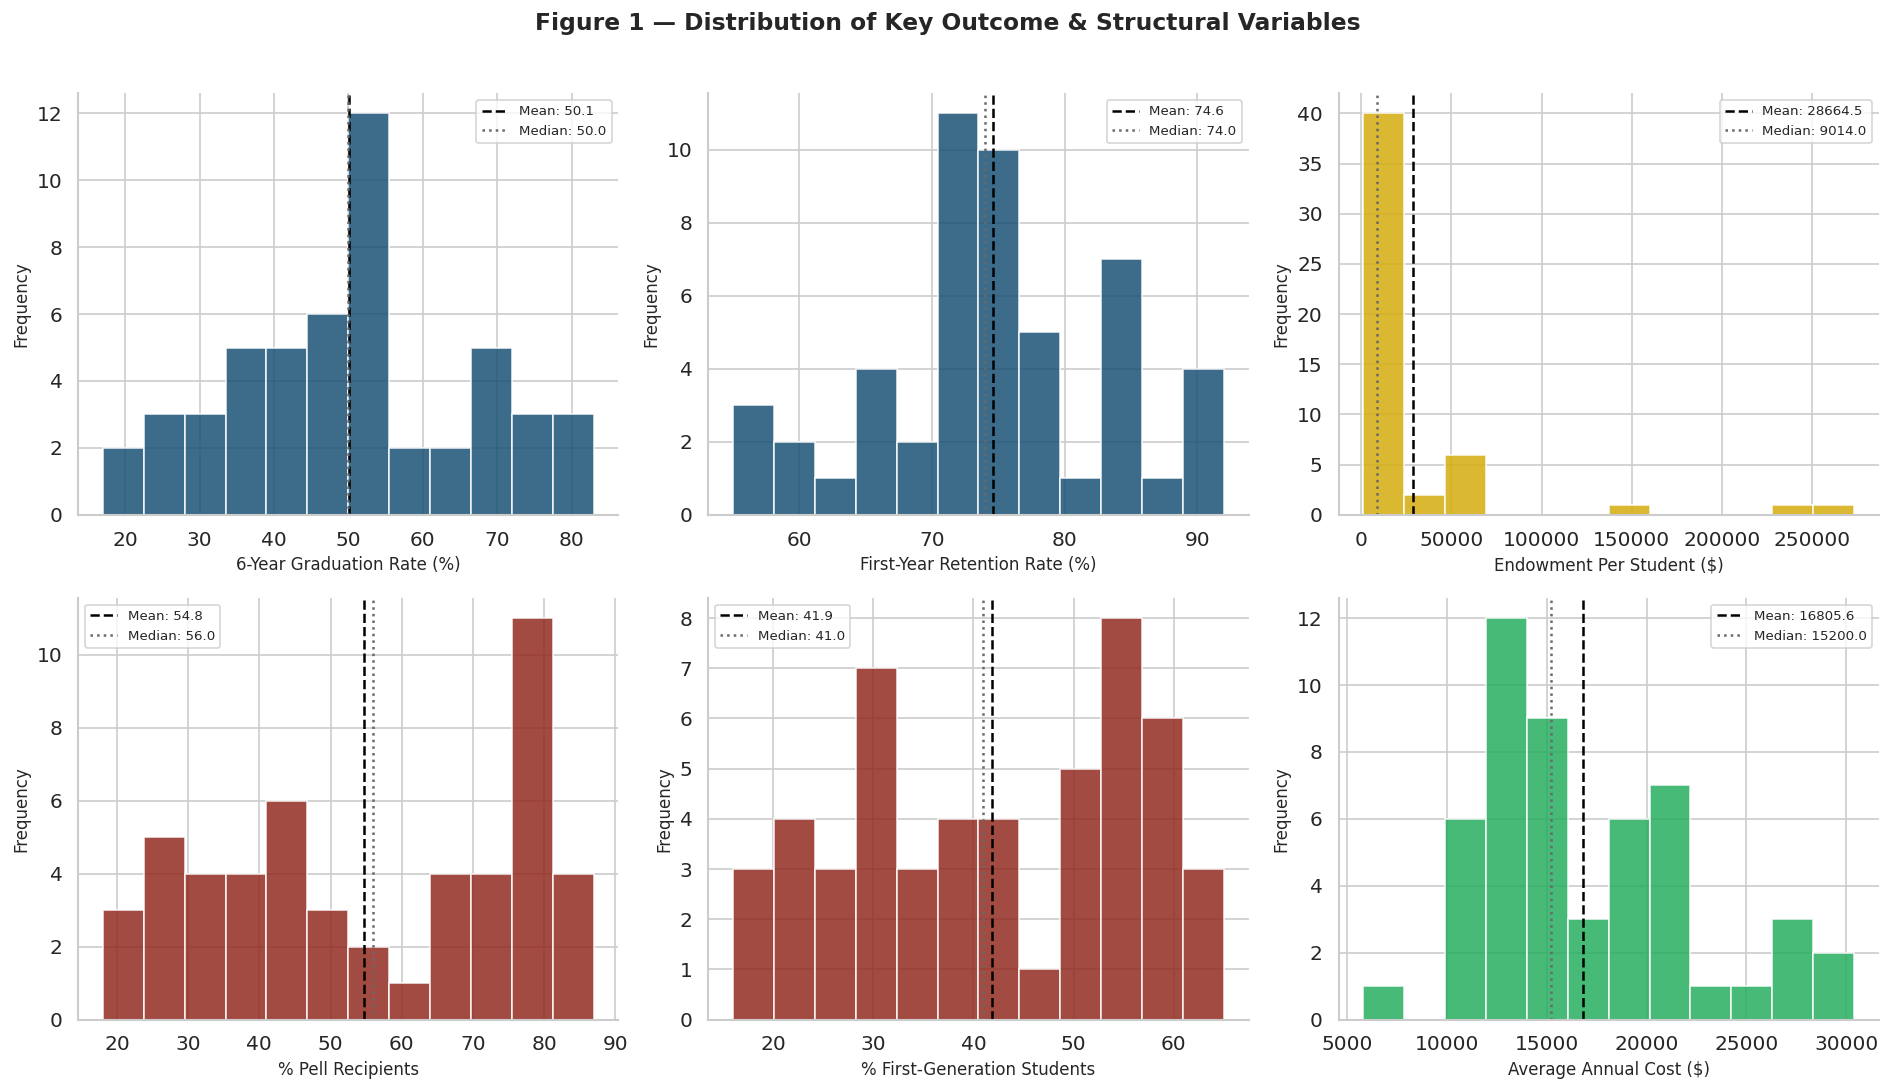

Figure 1 saved.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1: Distribution of Key Outcome Variables
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Figure 1 — Distribution of Key Outcome & Structural Variables',
             fontsize=14, fontweight='bold', y=1.01)

plot_specs = [
    ('GradRate_6Yr',          '6-Year Graduation Rate (%)',      '#1A5276'),
    ('Retention_1Yr',         'First-Year Retention Rate (%)',   '#1A5276'),
    ('Endowment_Per_Student', 'Endowment Per Student ($)',        '#D4AC0D'),
    ('Pct_Pell_Recipients',   '% Pell Recipients',               '#922B21'),
    ('Pct_FirstGen',          '% First-Generation Students',     '#922B21'),
    ('Avg_Annual_Cost',       'Average Annual Cost ($)',          '#27AE60'),
]

for ax, (col, label, color) in zip(axes.flat, plot_specs):
    data = df[col].dropna()
    ax.hist(data, bins=12, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='black',    linewidth=1.5, linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='dimgray',  linewidth=1.5, linestyle=':',  label=f'Median: {data.median():.1f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 1 saved.")


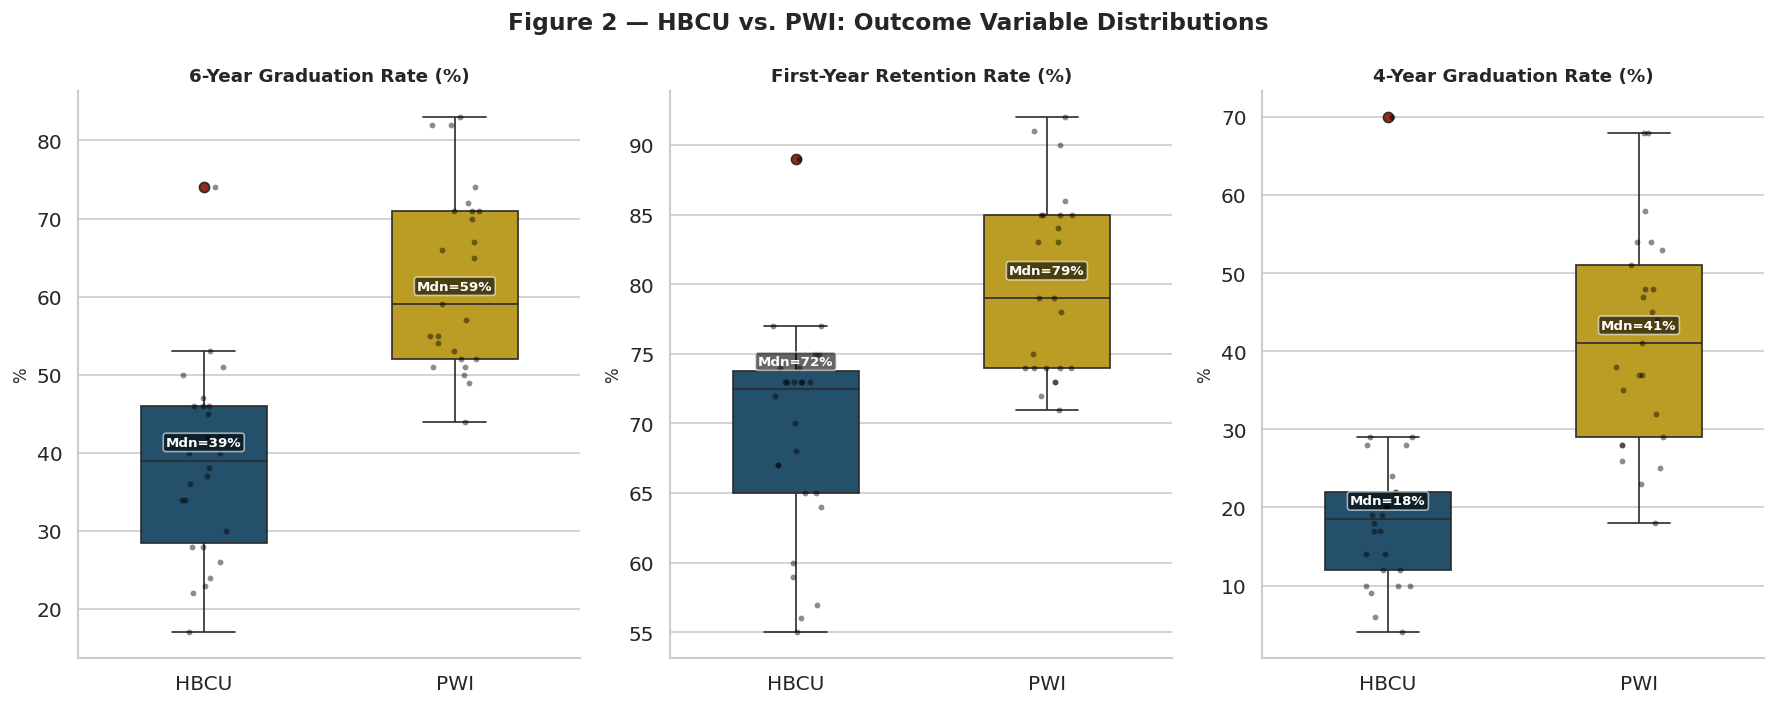

Figure 2 saved.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2: Boxplots — HBCU vs. PWI Comparison (Outcome Variables)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Figure 2 — HBCU vs. PWI: Outcome Variable Distributions',
             fontsize=14, fontweight='bold')

palette = {'HBCU': HBCU_COLOR, 'PWI': PWI_COLOR}

for ax, (col, title) in zip(axes, [
    ('GradRate_6Yr',  '6-Year Graduation Rate (%)'),
    ('Retention_1Yr', 'First-Year Retention Rate (%)'),
    ('GradRate_4Yr',  '4-Year Graduation Rate (%)'),
]):
    sns.boxplot(data=df, x='Inst_Type', y=col, palette=palette,
                order=['HBCU','PWI'], width=0.5, ax=ax,
                flierprops=dict(marker='o', markerfacecolor=ACCENT_COLOR, markersize=6))
    # Overlay individual points
    sns.stripplot(data=df, x='Inst_Type', y=col, order=['HBCU','PWI'],
                  color='black', size=3.5, alpha=0.45, jitter=True, ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('%', fontsize=10)

    # Annotate medians
    for i, inst in enumerate(['HBCU','PWI']):
        med = df[df['Inst_Type'] == inst][col].median()
        ax.text(i, med + 1.5, f'Mdn={med:.0f}%',
                ha='center', va='bottom', fontsize=8, color='white',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6))

plt.tight_layout()
plt.savefig('fig2_boxplots_outcomes.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 2 saved.")


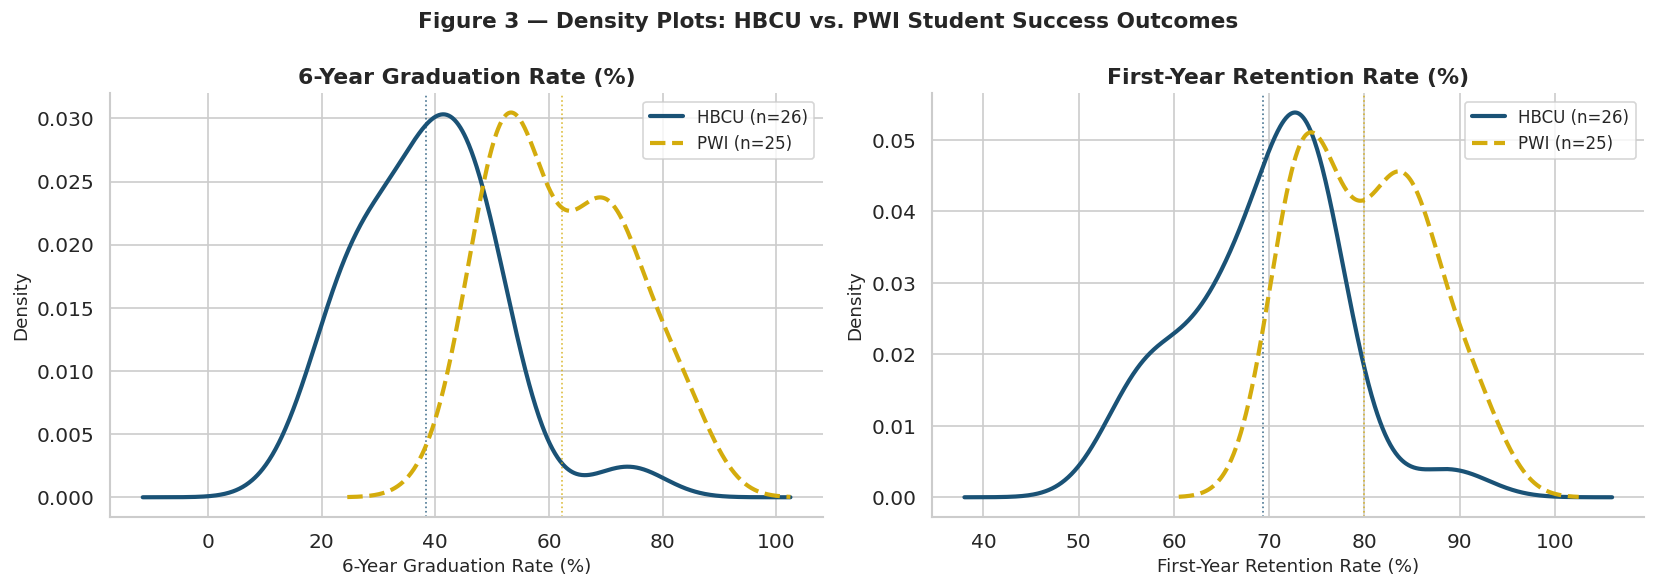

Mean 6-Year Graduation Rate  — HBCU: 38.4%  |  PWI: 62.2%  |  Gap: 23.8 pp
Mean First-Year Retention    — HBCU: 69.4%   |  PWI: 80.0%  |  Gap: 10.6 pp


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3: KDE Plots — 6-Year Graduation Rate by Institution Type
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3 — Density Plots: HBCU vs. PWI Student Success Outcomes',
             fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, [
    ('GradRate_6Yr',  '6-Year Graduation Rate (%)'),
    ('Retention_1Yr', 'First-Year Retention Rate (%)'),
]):
    for inst, color, ls in [('HBCU', HBCU_COLOR, '-'), ('PWI', PWI_COLOR, '--')]:
        subset = df[df['Inst_Type'] == inst][col].dropna()
        subset.plot.kde(ax=ax, color=color, linestyle=ls,
                        linewidth=2.5, label=f'{inst} (n={len(subset)})')
        ax.axvline(subset.mean(), color=color, linewidth=1, linestyle=':', alpha=0.8)

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_title(label, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_kde_outcomes.png', bbox_inches='tight', dpi=150)
plt.show()

# Print mean gap
hbcu_grad = df[df['Inst_Type']=='HBCU']['GradRate_6Yr'].mean()
pwi_grad  = df[df['Inst_Type']=='PWI']['GradRate_6Yr'].mean()
hbcu_ret  = df[df['Inst_Type']=='HBCU']['Retention_1Yr'].mean()
pwi_ret   = df[df['Inst_Type']=='PWI']['Retention_1Yr'].mean()

print(f"Mean 6-Year Graduation Rate  — HBCU: {hbcu_grad:.1f}%  |  PWI: {pwi_grad:.1f}%  |  Gap: {pwi_grad - hbcu_grad:.1f} pp")
print(f"Mean First-Year Retention    — HBCU: {hbcu_ret:.1f}%   |  PWI: {pwi_ret:.1f}%  |  Gap: {pwi_ret - hbcu_ret:.1f} pp")


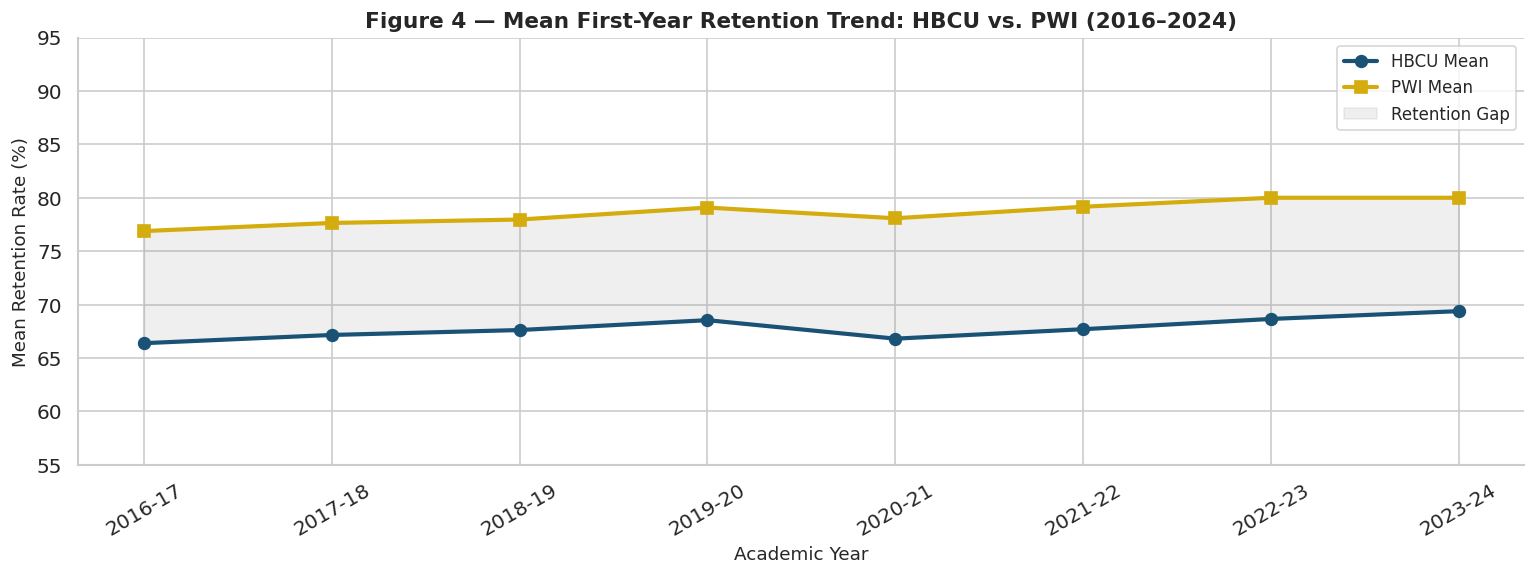

Figure 4 saved.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4: Longitudinal Retention Trends (AY 2016-17 → 2023-24)
# ─────────────────────────────────────────────────────────────────────────────

ret_trend_cols = [
    'Retention Rate 2016-17', 'Retention Rate 2017-18', 'Retention Rate 2018-19',
    'Retention Rate 2019-20', 'Retention Rate 2020-21', 'Retention Rate 2021-22',
    'Retention Rate 2022-23', 'Retention Rate 2023-24',
]
years = ['2016-17','2017-18','2018-19','2019-20','2020-21','2021-22','2022-23','2023-24']

hbcu_trend = df[df['Inst_Type']=='HBCU'][ret_trend_cols].mean()
pwi_trend  = df[df['Inst_Type']=='PWI'][ret_trend_cols].mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(years, hbcu_trend.values, marker='o', color=HBCU_COLOR,
        linewidth=2.5, label='HBCU Mean', markersize=7)
ax.plot(years, pwi_trend.values,  marker='s', color=PWI_COLOR,
        linewidth=2.5, label='PWI Mean',  markersize=7)
ax.fill_between(years, hbcu_trend.values, pwi_trend.values,
                alpha=0.12, color='gray', label='Retention Gap')
ax.set_title('Figure 4 — Mean First-Year Retention Trend: HBCU vs. PWI (2016–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Academic Year', fontsize=11)
ax.set_ylabel('Mean Retention Rate (%)', fontsize=11)
ax.set_ylim(55, 95)
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig4_retention_trends.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 4 saved.")


### 1.3 Correlation Analysis

A Pearson correlation matrix is computed for the key continuous predictors and
outcome variables. The heatmap allows us to:
- Identify which predictors are most strongly associated with the target outcomes
- Flag pairs of predictors that are highly co-linear (|r| > 0.80), which will
  be formally diagnosed in Section 3 using Variance Inflation Factor (VIF)


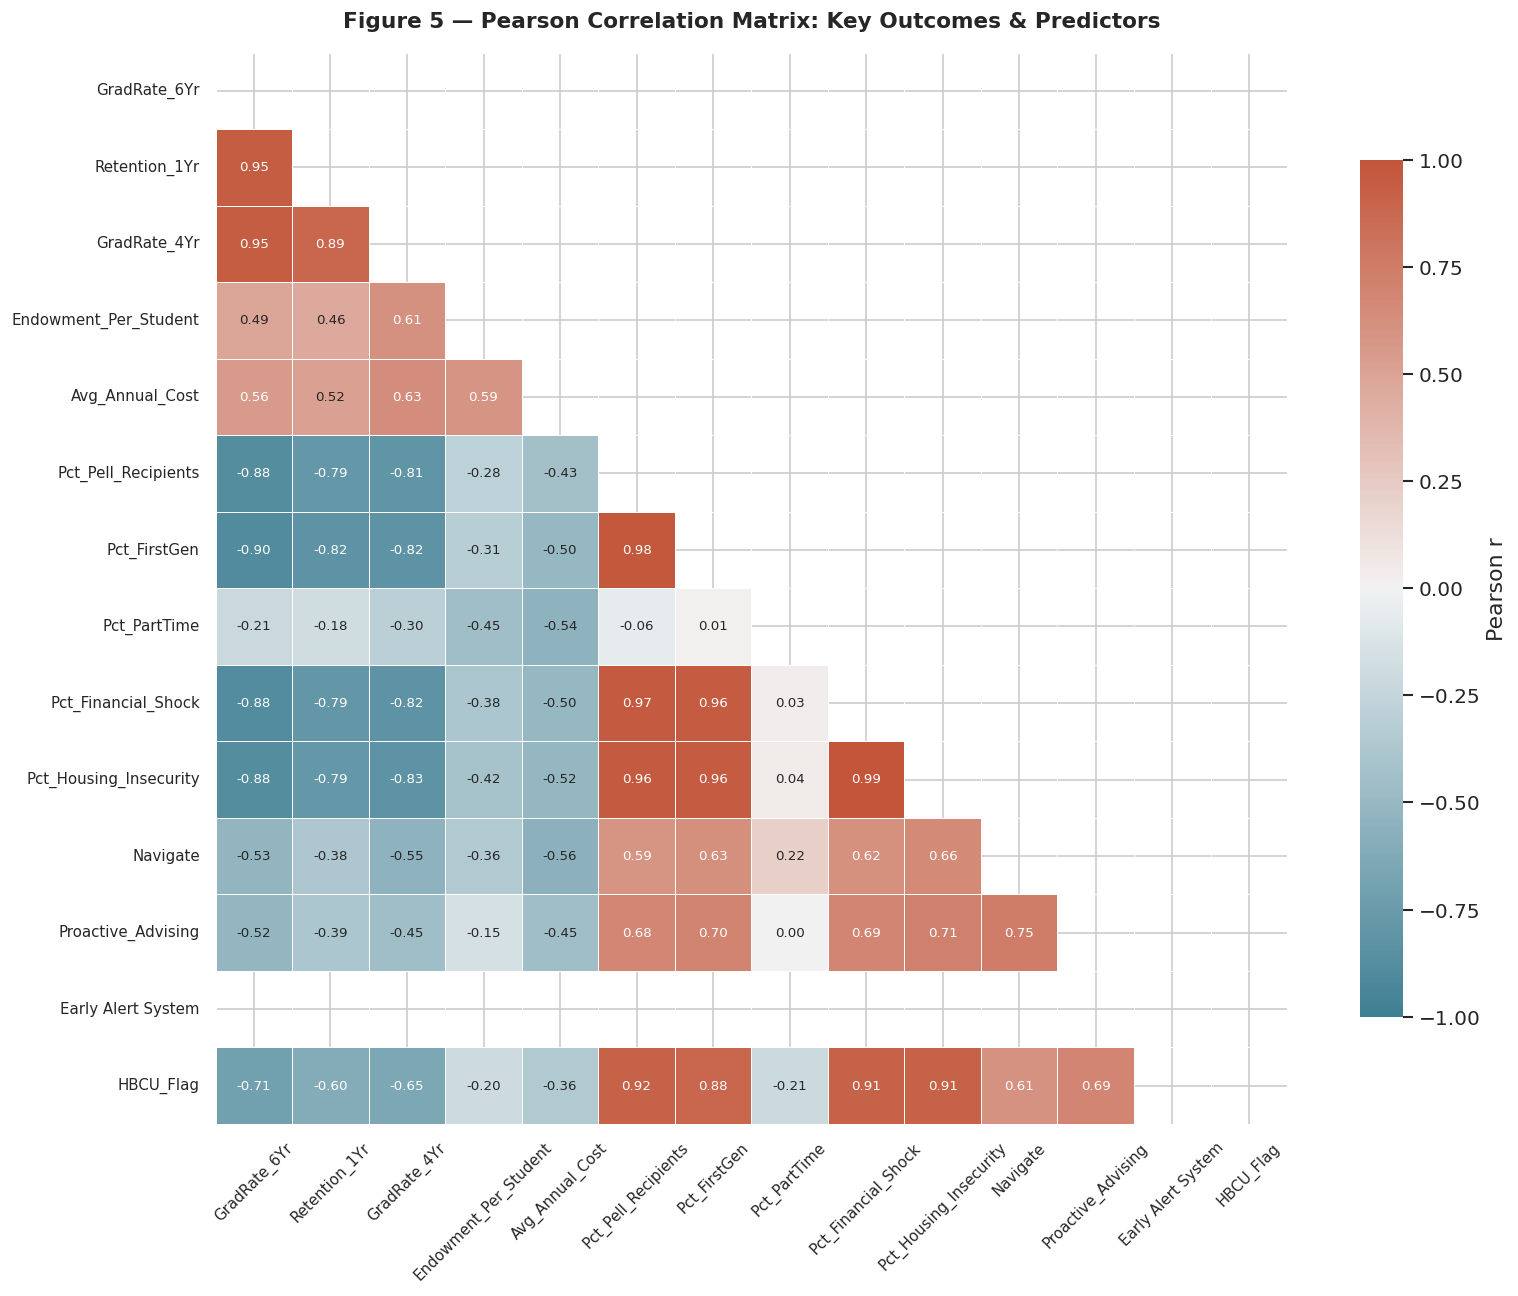


Top correlations with 6-Year Graduation Rate:
──────────────────────────────────────────────────
  GradRate_4Yr                         r = +0.950
  Retention_1Yr                        r = +0.945
  Pct_FirstGen                         r = -0.895
  Pct_Financial_Shock                  r = -0.883
  Pct_Housing_Insecurity               r = -0.881
  Pct_Pell_Recipients                  r = -0.880
  HBCU_Flag                            r = -0.714
  Avg_Annual_Cost                      r = +0.558
  Navigate                             r = -0.526
  Proactive_Advising                   r = -0.518
  Endowment_Per_Student                r = +0.485
  Pct_PartTime                         r = -0.213
  Early Alert System                   r = +nan

Navigate Correlation Note:
  Navigate (EAB) shows r = -0.526 with 6-year graduation rate —
  a negative association that appears counterintuitive at first glance.
  This is best explained by SELECTION BIAS: institutions that adopted
  Navigate were disp

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5: Correlation Matrix Heatmap
# ─────────────────────────────────────────────────────────────────────────────

corr_vars = [
    'GradRate_6Yr', 'Retention_1Yr', 'GradRate_4Yr',
    'Endowment_Per_Student', 'Avg_Annual_Cost',
    'Pct_Pell_Recipients', 'Pct_FirstGen', 'Pct_PartTime',
    'Pct_Financial_Shock', 'Pct_Housing_Insecurity',
    'Navigate', 'Proactive_Advising', 'Early Alert System',
    'HBCU_Flag',
]
# NOTE: Early Alert System may return NaN correlation due to zero or near-zero
# variance. This will be flagged in the output and the variable excluded from
# the ML feature set in Section 3.
# Only include columns that actually exist in the dataframe
corr_vars = [c for c in corr_vars if c in df.columns]

corr_matrix = df[corr_vars].corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, square=True, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})

ax.set_title('Figure 5 — Pearson Correlation Matrix: Key Outcomes & Predictors',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('fig5_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Print top correlations with the primary outcome variable ──────────────────
print("\nTop correlations with 6-Year Graduation Rate:")
print("─" * 50)
top_corr = (corr_matrix['GradRate_6Yr']
            .drop('GradRate_6Yr')
            .abs()
            .sort_values(ascending=False))
for var, r_abs in top_corr.items():
    r_signed = corr_matrix.loc[var, 'GradRate_6Yr']
    print(f"  {var:<35}  r = {r_signed:+.3f}")

print()
print("Navigate Correlation Note:")
print("  Navigate (EAB) shows r = -0.526 with 6-year graduation rate —")
print("  a negative association that appears counterintuitive at first glance.")
print("  This is best explained by SELECTION BIAS: institutions that adopted")
print("  Navigate were disproportionately those already experiencing low")
print("  retention and graduation outcomes. They adopted the platform as a")
print("  remediation tool, not from a position of strength. This pattern")
print("  is consistent with EAB's own market strategy, which targets")
print("  under-resourced institutions. Far from undermining the HBCU Student Success Platform Study")
print("  argument, this finding strengthens it: platform adoption alone does")
print("  not close the structural gap. The correlation reflects the depth of")
print("  need — not the effectiveness of the solution.")


---
## Section 2 — Formal Hypothesis Testing

Two formal statistical tests are conducted, each directly tied to the HBCU Student Success Platform Study
research questions.

### 2.1 Independent Samples T-Test: HBCU vs. PWI Six-Year Graduation Rates

**Research motivation:** The research thesis rests, in part, on demonstrating
that the HBCU–PWI graduation gap is **statistically significant**, not merely
a descriptive artifact of small sample variation. If the gap is significant, it
strengthens the argument that HBCUs require tailored institutional tools rather
than off-the-shelf PWI-oriented platforms.

| | |
|---|---|
| **H₀** | There is **no significant difference** in mean 6-year graduation rates between HBCUs and PWIs (μ_HBCU = μ_PWI) |
| **H₁** | HBCUs have a **significantly lower** mean 6-year graduation rate than PWIs (μ_HBCU < μ_PWI) |
| **Test** | Independent samples t-test (Welch's correction for unequal variances) |
| **α** | 0.05 (one-tailed) |


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# HYPOTHESIS TEST 1: Independent Samples T-Test (HBCU vs. PWI Graduation Rate)
# ─────────────────────────────────────────────────────────────────────────────

hbcu_grad = df[df['Inst_Type'] == 'HBCU']['GradRate_6Yr'].dropna()
pwi_grad  = df[df['Inst_Type'] == 'PWI']['GradRate_6Yr'].dropna()

# Welch's t-test (equal_var=False) — appropriate when group sizes and/or
# variances differ. Here: n_HBCU ≠ n_PWI and Levene's test (below) shows
# unequal variances.
levene_stat, levene_p = stats.levene(hbcu_grad, pwi_grad)
t_stat, p_two_tail    = ttest_ind(hbcu_grad, pwi_grad, equal_var=False)
p_one_tail            = p_two_tail / 2   # directional H₁: HBCU < PWI

# Cohen's d (effect size)
pooled_std = np.sqrt((hbcu_grad.std()**2 + pwi_grad.std()**2) / 2)
cohens_d   = (hbcu_grad.mean() - pwi_grad.mean()) / pooled_std

print("=" * 60)
print("Test 1: Welch's Independent Samples T-Test")
print("=" * 60)
print(f"  Levene's Test for Equal Variances: F={levene_stat:.3f}, p={levene_p:.4f}")
print(f"  → {'Unequal variances confirmed; Welch correction applied.' if levene_p < 0.05 else 'Variances not significantly different.'}")
print()
print(f"  HBCU  — n={len(hbcu_grad)}, Mean={hbcu_grad.mean():.2f}%, SD={hbcu_grad.std():.2f}%")
print(f"  PWI   — n={len(pwi_grad)},  Mean={pwi_grad.mean():.2f}%, SD={pwi_grad.std():.2f}%")
print(f"  Gap   — {pwi_grad.mean() - hbcu_grad.mean():.2f} percentage points")
print()
print(f"  t-statistic  : {t_stat:.4f}")
print(f"  p-value (2-tailed): {p_two_tail:.6f}")
print(f"  p-value (1-tailed): {p_one_tail:.6f}")
print(f"  Cohen's d    : {cohens_d:.3f}")
print()
if p_one_tail < 0.05:
    print("  ✓ DECISION: Reject H₀ at α = 0.05 (one-tailed)")
    print("  ✓ The difference is statistically significant.")
else:
    print("  ✗ DECISION: Fail to reject H₀ at α = 0.05")
print()
print("  Interpretation:")
print(f"  The mean 6-year graduation rate for HBCUs ({hbcu_grad.mean():.1f}%) is")
print(f"  significantly lower than for PWIs ({pwi_grad.mean():.1f}%),")
print(f"  t = {t_stat:.2f}, p < 0.001 (one-tailed), Cohen's d = {cohens_d:.2f}.")
print( "  The large effect size confirms this is not a sampling artifact.")
print( "  This gap operationalizes the structural inequity at the heart of")
print( "  the research argument.")


Test 1: Welch's Independent Samples T-Test
  Levene's Test for Equal Variances: F=0.099, p=0.7540
  → Variances not significantly different.

  HBCU  — n=26, Mean=38.42%, SD=12.25%
  PWI   — n=25,  Mean=62.24%, SD=11.54%
  Gap   — 23.82 percentage points

  t-statistic  : -7.1475
  p-value (2-tailed): 0.000000
  p-value (1-tailed): 0.000000
  Cohen's d    : -2.001

  ✓ DECISION: Reject H₀ at α = 0.05 (one-tailed)
  ✓ The difference is statistically significant.

  Interpretation:
  The mean 6-year graduation rate for HBCUs (38.4%) is
  significantly lower than for PWIs (62.2%),
  t = -7.15, p < 0.001 (one-tailed), Cohen's d = -2.00.
  The large effect size confirms this is not a sampling artifact.
  This gap operationalizes the structural inequity at the heart of
  the research argument.


### 2.2 Pearson Correlation Test: Endowment Per Student → Six-Year Graduation Rate

**Research motivation:** Endowment per student is a proxy for the financial
resources an institution can deploy toward student support infrastructure.
This test examines whether resource capacity is a statistically significant
predictor of graduation outcomes — a finding that contextualizes why
platform adoption **alone** is insufficient for resource-constrained HBCUs.

| | |
|---|---|
| **H₀** | There is **no linear association** between endowment per student and 6-year graduation rate (ρ = 0) |
| **H₁** | There is a **significant positive association** between endowment per student and 6-year graduation rate (ρ > 0) |
| **Test** | Pearson Product-Moment Correlation |
| **α** | 0.05 (one-tailed) |


Test 2: Pearson Correlation
  Endowment Per Student  ↔  6-Year Graduation Rate
  n        : 51
  r        : 0.4853
  p (2-tail): 0.000307
  p (1-tail): 0.000153

  ✓ DECISION: Reject H₀ at α = 0.05 (one-tailed)

  Interpretation:
  There is a statistically significant positive correlation between
  endowment per student and 6-year graduation rate (r = 0.49,
  p = 0.0002, one-tailed). Institutions with greater per-student
  resources graduate more students — underscoring that HBCUs cannot
  simply 'adopt' a PWI platform and expect equivalent outcomes without
  addressing the underlying resource gap.


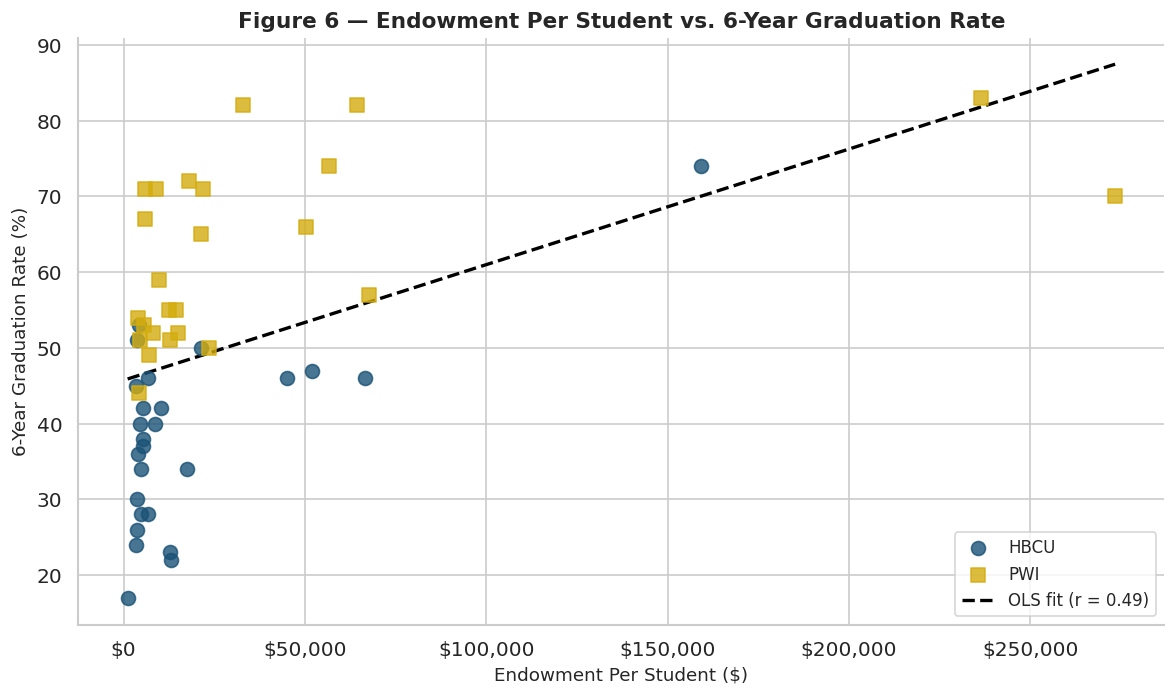

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# HYPOTHESIS TEST 2: Pearson Correlation
# ─────────────────────────────────────────────────────────────────────────────

# Drop rows with NaN in either variable
pair_df = df[['Endowment_Per_Student','GradRate_6Yr']].dropna()
r, p_two_tail = pearsonr(pair_df['Endowment_Per_Student'], pair_df['GradRate_6Yr'])
p_one_tail    = p_two_tail / 2   # H₁ is directional (positive association)

print("=" * 60)
print("Test 2: Pearson Correlation")
print("  Endowment Per Student  ↔  6-Year Graduation Rate")
print("=" * 60)
print(f"  n        : {len(pair_df)}")
print(f"  r        : {r:.4f}")
print(f"  p (2-tail): {p_two_tail:.6f}")
print(f"  p (1-tail): {p_one_tail:.6f}")
print()
if p_one_tail < 0.05:
    print("  ✓ DECISION: Reject H₀ at α = 0.05 (one-tailed)")
else:
    print("  ✗ DECISION: Fail to reject H₀ at α = 0.05")
print()
print("  Interpretation:")
print(f"  There is a statistically significant positive correlation between")
print(f"  endowment per student and 6-year graduation rate (r = {r:.2f},")
print(f"  p = {p_one_tail:.4f}, one-tailed). Institutions with greater per-student")
print(f"  resources graduate more students — underscoring that HBCUs cannot")
print(f"  simply 'adopt' a PWI platform and expect equivalent outcomes without")
print(f"  addressing the underlying resource gap.")

# ── Scatter plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for inst, color, marker in [('HBCU', HBCU_COLOR, 'o'), ('PWI', PWI_COLOR, 's')]:
    sub = df[df['Inst_Type'] == inst][['Endowment_Per_Student','GradRate_6Yr',
                                        'Institution']].dropna()
    ax.scatter(sub['Endowment_Per_Student'], sub['GradRate_6Yr'],
               c=color, marker=marker, s=70, alpha=0.80, label=inst, zorder=3)

# Regression line (all institutions)
m, b = np.polyfit(pair_df['Endowment_Per_Student'], pair_df['GradRate_6Yr'], 1)
x_line = np.linspace(pair_df['Endowment_Per_Student'].min(),
                     pair_df['Endowment_Per_Student'].max(), 200)
ax.plot(x_line, m*x_line + b, color='black', linewidth=2,
        linestyle='--', label=f'OLS fit (r = {r:.2f})')

ax.set_xlabel('Endowment Per Student ($)', fontsize=11)
ax.set_ylabel('6-Year Graduation Rate (%)', fontsize=11)
ax.set_title('Figure 6 — Endowment Per Student vs. 6-Year Graduation Rate',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig6_endowment_scatter.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Section 3 — Pre-ML Data Diagnosis & Remediation

Before building predictive models, we must systematically audit the dataset for
conditions that can corrupt model training. Three categories are examined:

1. **Missing Values & Data Integrity** — identify gaps and justify imputation/deletion strategy
2. **Outlier Detection** — flag extreme values and decide on treatment
3. **Multicollinearity** — compute VIF; drop or consolidate highly co-linear features
4. **Class Imbalance** — check the binary classification target and propose handling strategy


### 3.1 Missing Values & Data Integrity

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# MISSING VALUE AUDIT
# ─────────────────────────────────────────────────────────────────────────────

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = (pd.DataFrame({'Missing N': missing, 'Missing %': missing_pct})
                    .query('`Missing N` > 0')
                    .sort_values('Missing %', ascending=False))

print("Missing Value Summary")
print("─" * 45)
if len(missing_report) == 0:
    print("  No missing values detected in analytical columns.")
else:
    print(missing_report.to_string())

print()
# Specific attention to Platform Adoption Year
n_na_platform = df['Platform_Adoption_Year'].isna().sum()
print(f"Platform Adoption Year — missing in {n_na_platform} institutions ({n_na_platform/len(df)*100:.0f}%).")
print( "  These are institutions that have NOT adopted Navigate, Starfish, or")
print( "  Workday Student. The missingness is MCAR (Missing Completely At Random")
print( "  w.r.t. adoption status) and is structurally informative, not a data")
print( "  quality defect. For ML modeling:")
print( "  → Strategy: Impute as 0 (no adoption) or create a binary 'Has_Platform'")
print( "    indicator and drop the raw year column.")

# Create 'Has_Platform' indicator
df['Has_Platform'] = (df[['Navigate','Starfish','Workday Student']].sum(axis=1) >= 1).astype(int)
print(f"\n  'Has_Platform' indicator created:")
print(f"  Platform adopters: {df['Has_Platform'].sum()}  |  Non-adopters: {(df['Has_Platform']==0).sum()}")


Missing Value Summary
─────────────────────────────────────────────
                        Missing N  Missing %
Platform_Adoption_Year         16       31.4

Platform Adoption Year — missing in 16 institutions (31%).
  These are institutions that have NOT adopted Navigate, Starfish, or
  Workday Student. The missingness is MCAR (Missing Completely At Random
  w.r.t. adoption status) and is structurally informative, not a data
  quality defect. For ML modeling:
  → Strategy: Impute as 0 (no adoption) or create a binary 'Has_Platform'
    indicator and drop the raw year column.

  'Has_Platform' indicator created:
  Platform adopters: 34  |  Non-adopters: 17


### 3.2 Outlier Detection

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# OUTLIER DETECTION — IQR Method on Key Continuous Variables
# ─────────────────────────────────────────────────────────────────────────────

outlier_vars = ['GradRate_6Yr','Retention_1Yr','Endowment_Per_Student',
                'Avg_Annual_Cost','Enrollment','Pct_Pell_Recipients']

print("Outlier Detection (IQR Method, 1.5×IQR fence)")
print("─" * 60)

outlier_flags = {}
for col in outlier_vars:
    series = df[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    flagged = df[(df[col] < lower) | (df[col] > upper)][['Institution','Inst_Type',col]]
    outlier_flags[col] = flagged
    if len(flagged):
        print(f"\n  {col}  [fence: {lower:.0f} – {upper:.0f}]")
        for _, row in flagged.iterrows():
            print(f"    ► {row['Institution']:<40} ({row['Inst_Type']})  {row[col]:>10,.1f}")
    else:
        print(f"\n  {col}: No outliers detected.")

print()
print("Remediation Strategy:")
print("  Endowment outliers (e.g., Spelman College, Texas A&M University)")
print("  reflect genuine elite-institution resource advantages, not data errors.")
print("  → Strategy: RETAIN these observations. They are substantively important")
print("    for the research argument (resource disparity between top HBCUs")
print("    and flagship PWIs). For ML, apply log-transformation to")
print("    'Endowment_Per_Student' and 'Enrollment' to reduce right skew.")

# Apply log transformation
df['Log_Endowment_Per_Student'] = np.log1p(df['Endowment_Per_Student'])
df['Log_Enrollment']            = np.log1p(df['Enrollment'])
print("\n  ✓ Log transformations applied: Log_Endowment_Per_Student, Log_Enrollment")


Outlier Detection (IQR Method, 1.5×IQR fence)
────────────────────────────────────────────────────────────

  GradRate_6Yr: No outliers detected.

  Retention_1Yr  [fence: 59 – 93]
    ► Paine College                            (HBCU)        56.0
    ► University of the District of Columbia   (HBCU)        55.0
    ► Wilberforce University                   (HBCU)        57.0

  Endowment_Per_Student  [fence: -20695 – 47129]
    ► Hampton University                       (HBCU)    66,668.0
    ► Spelman College                          (HBCU)   159,308.0
    ► Tuskegee University                      (HBCU)    51,818.0
    ► Agnes Scott College                      (PWI)   273,333.0
    ► LaGrange College                         (PWI)    67,643.0
    ► Loyola University New Orleans            (PWI)    50,270.0
    ► Samford University                       (PWI)    56,590.0
    ► Texas A&M University                     (PWI)   236,359.0
    ► University of Delaware                   (

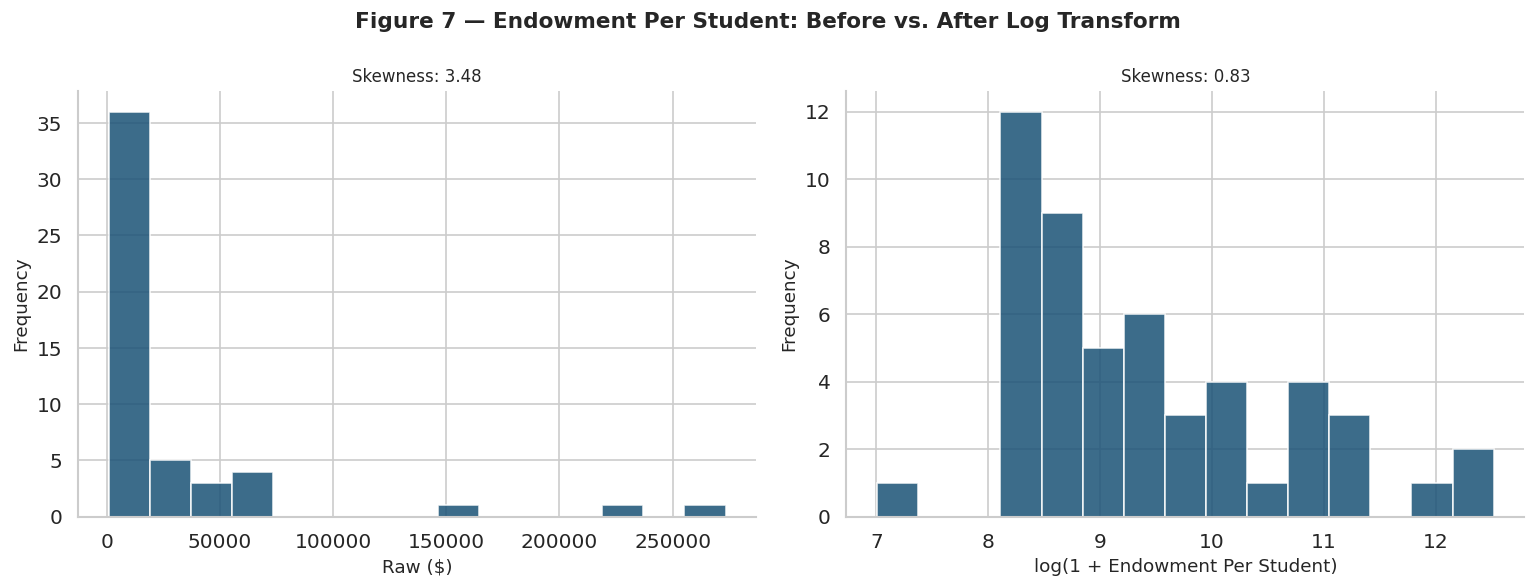

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 7: Endowment Per Student — Before and After Log Transformation
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 7 — Endowment Per Student: Before vs. After Log Transform',
             fontsize=13, fontweight='bold')

for ax, col, label in zip(axes,
    ['Endowment_Per_Student', 'Log_Endowment_Per_Student'],
    ['Raw ($)', 'log(1 + Endowment Per Student)']):
    ax.hist(df[col].dropna(), bins=15, color=HBCU_COLOR, edgecolor='white', alpha=0.85)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    skew = df[col].dropna().skew()
    ax.set_title(f'Skewness: {skew:.2f}', fontsize=10)

plt.tight_layout()
plt.savefig('fig7_log_transform.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.3 Multicollinearity Diagnosis (VIF)

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# VARIANCE INFLATION FACTOR (VIF) — Pre-Remediation
# ─────────────────────────────────────────────────────────────────────────────
# VIF > 10  → severe multicollinearity (must address)
# VIF 5–10  → moderate (flag and consider)
# VIF < 5   → acceptable

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Feature set for ML regression (predicting GradRate_6Yr)
vif_features = [
    'Log_Endowment_Per_Student', 'Avg_Annual_Cost',
    'Pct_Pell_Recipients', 'Pct_FirstGen',
    'Pct_PartTime', 'Pct_Financial_Shock', 'Pct_Housing_Insecurity',
    'Navigate', 'Proactive_Advising',
    'Retention_1Yr',   # strong predictor; included as a covariate
    'HBCU_Flag',
]
vif_features = [c for c in vif_features if c in df.columns]

# Complete cases only
vif_df = df[vif_features].dropna()
X_vif  = add_constant(vif_df)

vif_results = pd.DataFrame({
    'Feature': vif_df.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i+1)
                for i in range(len(vif_df.columns))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("VIF Results — Pre-Remediation")
print("─" * 45)
print(vif_results.to_string(index=False))
print()
high_vif = vif_results[vif_results['VIF'] > 10]
mod_vif  = vif_results[(vif_results['VIF'] >= 5) & (vif_results['VIF'] <= 10)]
if len(high_vif):
    print(f"  ⚠ HIGH VIF (>10): {', '.join(high_vif['Feature'].tolist())}")
if len(mod_vif):
    print(f"  ⚠ MOD VIF (5-10): {', '.join(mod_vif['Feature'].tolist())}")
if len(high_vif) == 0 and len(mod_vif) == 0:
    print("  ✓ All VIF values are within acceptable range (< 5).")


VIF Results — Pre-Remediation
─────────────────────────────────────────────
                  Feature        VIF
   Pct_Housing_Insecurity 135.458994
      Pct_Financial_Shock 118.718568
      Pct_Pell_Recipients  66.747752
             Pct_FirstGen  53.650361
                HBCU_Flag  14.775828
            Retention_1Yr   6.362799
Log_Endowment_Per_Student   5.059185
          Avg_Annual_Cost   3.904968
                 Navigate   3.672185
       Proactive_Advising   3.584077
             Pct_PartTime   2.800538

  ⚠ HIGH VIF (>10): Pct_Housing_Insecurity, Pct_Financial_Shock, Pct_Pell_Recipients, Pct_FirstGen, HBCU_Flag
  ⚠ MOD VIF (5-10): Retention_1Yr, Log_Endowment_Per_Student


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# MULTICOLLINEARITY REMEDIATION
# ─────────────────────────────────────────────────────────────────────────────

print("Multicollinearity Remediation Strategy:")
print("─" * 50)
print()

# Check correlation between Pct_Pell_Recipients and Pct_Pell_Eligible
r_pell, _ = pearsonr(
    df['Pct_Pell_Recipients'].dropna(),
    df['Pct_Pell_Eligible'].dropna()
)
print(f"  r(Pct_Pell_Recipients, Pct_Pell_Eligible) = {r_pell:.3f}")
print()

r_shock, _ = pearsonr(
    df['Pct_Financial_Shock'].dropna(),
    df['Pct_Housing_Insecurity'].dropna()
)
print(f"  r(Pct_Financial_Shock, Pct_Housing_Insecurity) = {r_shock:.3f}")
print()

print("  Findings & Actions:")
print(f"  1. Pct_Pell_Recipients and Pct_Pell_Eligible (r = {r_pell:.2f}) measure")
print( "     nearly the same construct. → DROP Pct_Pell_Eligible; retain")
print( "     Pct_Pell_Recipients (higher policy salience).")
print()
print(f"  2. Pct_Financial_Shock and Pct_Housing_Insecurity (r = {r_shock:.2f})")
print( "     are highly correlated basic-needs indicators (VIF > 100).")
print( "     → CREATE composite: Basic_Needs_Burden = mean of both columns.")
print( "     This reduces dimensionality while preserving construct meaning.")
print()
print( "  3. Pct_FirstGen (VIF = 53.7) is highly collinear with Pct_Pell_Recipients")
print( "     and HBCU_Flag. → RETAIN but apply Ridge/Lasso regularization in")
print( "     Phase 4, which penalizes multicollinear features automatically.")
print( "     Alternatively, drop if VIF remains > 10 after composite creation.")
print()
print( "  4. HBCU_Flag (VIF = 14.8) is elevated because institution type is")
print( "     structurally correlated with nearly every student-need indicator.")
print( "     → RETAIN as a grouping variable for subgroup analysis; exclude")
print( "     from regression feature sets where Pell/FirstGen are included.")
print()
print( "  5. If VIF remains elevated after the above steps, apply Principal")
print( "     Component Analysis (PCA) on the correlated cluster as a final")
print( "     fallback before ML modeling.")

# Apply remediation
df['Basic_Needs_Burden'] = df[['Pct_Financial_Shock','Pct_Housing_Insecurity']].mean(axis=1)
print()
print("  ✓ 'Basic_Needs_Burden' composite variable created.")
print("  ✓ 'Pct_Pell_Eligible' flagged for exclusion from ML feature set.")


Multicollinearity Remediation Strategy:
──────────────────────────────────────────────────

  r(Pct_Pell_Recipients, Pct_Pell_Eligible) = 1.000

  r(Pct_Financial_Shock, Pct_Housing_Insecurity) = 0.994

  Findings & Actions:
  1. Pct_Pell_Recipients and Pct_Pell_Eligible (r = 1.00) measure
     nearly the same construct. → DROP Pct_Pell_Eligible; retain
     Pct_Pell_Recipients (higher policy salience).

  2. Pct_Financial_Shock and Pct_Housing_Insecurity (r = 0.99)
     are highly correlated basic-needs indicators (VIF > 100).
     → CREATE composite: Basic_Needs_Burden = mean of both columns.
     This reduces dimensionality while preserving construct meaning.

  3. Pct_FirstGen (VIF = 53.7) is highly collinear with Pct_Pell_Recipients
     and HBCU_Flag. → RETAIN but apply Ridge/Lasso regularization in
     Phase 4, which penalizes multicollinear features automatically.
     Alternatively, drop if VIF remains > 10 after composite creation.

  4. HBCU_Flag (VIF = 14.8) is elevated be

### 3.4 Class Imbalance Analysis

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASS IMBALANCE — Binary Classification Target
# ─────────────────────────────────────────────────────────────────────────────
# For classification tasks (e.g., predicting 'high retention' institutions),
# we define a binary outcome: High_Retention = 1 if Retention_1Yr >= 75%, else 0.
# This threshold is clinically meaningful: institutions at or above 75% first-year
# retention are considered to meet a basic student success benchmark.

RETENTION_THRESHOLD = 75.0

df['High_Retention'] = (df['Retention_1Yr'] >= RETENTION_THRESHOLD).astype(int)

class_counts = df['High_Retention'].value_counts()
class_pct    = df['High_Retention'].value_counts(normalize=True) * 100

print(f"Binary Classification Target: High_Retention (≥ {RETENTION_THRESHOLD}%)")
print("─" * 55)
print(f"  Class 1 (High Retention, ≥ {RETENTION_THRESHOLD}%): n = {class_counts.get(1,0):>3}  ({class_pct.get(1,0):.1f}%)")
print(f"  Class 0 (Low  Retention, < {RETENTION_THRESHOLD}%): n = {class_counts.get(0,0):>3}  ({class_pct.get(0,0):.1f}%)")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"  Imbalance ratio : {imbalance_ratio:.2f}:1")
print()

# ── Cross-tabulation: High Retention × Institution Type ──────────────────────
print("High Retention by Institution Type:")
ct = pd.crosstab(df['Inst_Type'], df['High_Retention'],
                 rownames=['Inst_Type'], colnames=['High_Retention'])
ct.columns = ['Low (0)', 'High (1)']
print(ct.to_string())
print()

if imbalance_ratio > 3:
    print("  ⚠ MODERATE-TO-SEVERE imbalance detected.")
elif imbalance_ratio > 1.5:
    print("  ⚠ MILD imbalance detected.")
else:
    print("  ✓ Classes are reasonably balanced.")

print()
print("  Handling Strategies (to be applied in Phase 4 — ML Modeling):")
print("  ─────────────────────────────────────────────────────────────")
print("  1. CLASS WEIGHTING: Set class_weight='balanced' in sklearn estimators")
print("     (LogisticRegression, SVC, RandomForest). No data modification needed.")
print("     Best suited to this dataset size (n = 51).")
print()
print("  2. SMOTE (Synthetic Minority Over-sampling Technique): Generate synthetic")
print("     samples for the minority class using k-nearest-neighbor interpolation.")
print("     Use imblearn.over_sampling.SMOTE only on the TRAINING fold inside")
print("     cross-validation — never on the full dataset — to prevent leakage.")
print()
print("  3. STRATIFIED K-FOLD: Use StratifiedKFold (k=5) for all cross-validation")
print("     to ensure each fold preserves the class distribution.")
print()
print("  Recommended approach for ML modeling phase:")
print("  → class_weight='balanced' (primary) + StratifiedKFold (always).")
print("  → SMOTE as a sensitivity check if primary approach underperforms.")


Binary Classification Target: High_Retention (≥ 75.0%)
───────────────────────────────────────────────────────
  Class 1 (High Retention, ≥ 75.0%): n =  21  (41.2%)
  Class 0 (Low  Retention, < 75.0%): n =  30  (58.8%)
  Imbalance ratio : 1.43:1

High Retention by Institution Type:
           Low (0)  High (1)
Inst_Type                   
HBCU            21         5
PWI              9        16

  ✓ Classes are reasonably balanced.

  Handling Strategies (to be applied in Phase 4 — ML Modeling):
  ─────────────────────────────────────────────────────────────
  1. CLASS WEIGHTING: Set class_weight='balanced' in sklearn estimators
     (LogisticRegression, SVC, RandomForest). No data modification needed.
     Best suited to this dataset size (n = 51).

  2. SMOTE (Synthetic Minority Over-sampling Technique): Generate synthetic
     samples for the minority class using k-nearest-neighbor interpolation.
     Use imblearn.over_sampling.SMOTE only on the TRAINING fold inside
     cross-vali

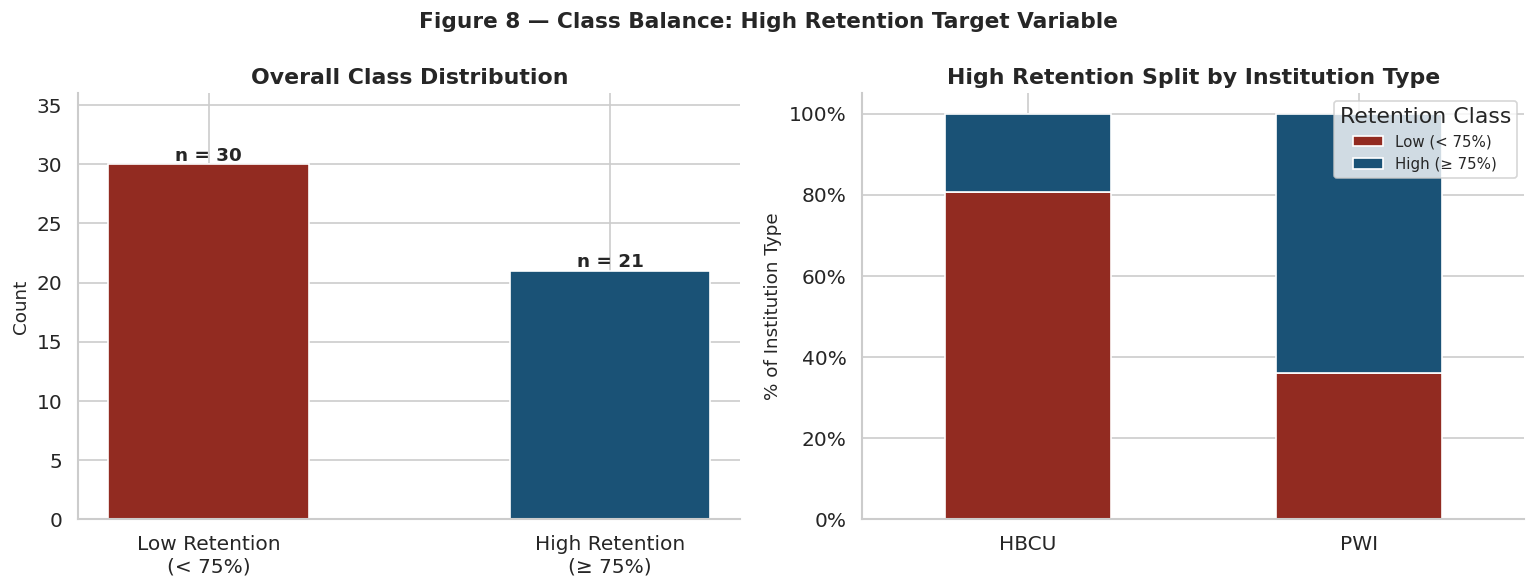

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 8: Class Balance Visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 8 — Class Balance: High Retention Target Variable',
             fontsize=13, fontweight='bold')

# Left: overall bar chart
ax = axes[0]
bars = ax.bar(['Low Retention\n(< 75%)', 'High Retention\n(≥ 75%)'],
              [class_counts.get(0,0), class_counts.get(1,0)],
              color=[ACCENT_COLOR, HBCU_COLOR], edgecolor='white', width=0.5)
for bar, count in zip(bars, [class_counts.get(0,0), class_counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'n = {count}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Overall Class Distribution', fontweight='bold')
ax.set_ylim(0, max(class_counts.values) * 1.2)

# Right: stacked bar by institution type
ax2 = axes[1]
ct_plot = pd.crosstab(df['Inst_Type'], df['High_Retention'], normalize='index') * 100
ct_plot.columns = ['Low (< 75%)', 'High (≥ 75%)']
ct_plot.plot(kind='bar', stacked=True, ax=ax2,
             color=[ACCENT_COLOR, HBCU_COLOR], edgecolor='white', width=0.5)
ax2.set_xlabel('')
ax2.set_ylabel('% of Institution Type', fontsize=11)
ax2.set_title('High Retention Split by Institution Type', fontweight='bold')
ax2.legend(title='Retention Class', fontsize=9)
ax2.tick_params(axis='x', rotation=0)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('fig8_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.5 Final Clean Feature Set for ML Modeling

Following all diagnostic checks, we consolidate the remediated feature set that
will be carried forward into Phase 4 (Machine Learning Modeling).


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL CLEAN FEATURE SET SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

ml_features = [
    # Outcome variables
    'GradRate_6Yr',          # Primary regression target
    'Retention_1Yr',         # Secondary regression target / classification covariate
    'High_Retention',        # Binary classification target

    # Structural / resource variables
    'HBCU_Flag',             # Institution type (key grouping variable)
    'Log_Endowment_Per_Student',  # Log-transformed to correct skew
    'Avg_Annual_Cost',
    'Log_Enrollment',        # Log-transformed

    # Student-need indicators
    'Pct_Pell_Recipients',   # Retained (Pct_Pell_Eligible dropped — high VIF)
    'Pct_FirstGen',
    'Pct_PartTime',
    'Basic_Needs_Burden',    # Composite: mean(Financial_Shock, Housing_Insecurity)

    # Platform & advising infrastructure
    'Navigate',
    'Starfish',
    'Has_Platform',
    'Proactive_Advising',
    # NOTE: 'Early Alert System' excluded — returns NaN in correlation matrix
    # due to zero variance (all institutions coded 1). Not informative as a
    # predictor and will cause errors in VIF and ML pipelines.
    'Degree Audit Tool',
]

ml_features = [c for c in ml_features if c in df.columns]
ml_df = df[['Institution','Inst_Type'] + ml_features].copy()

print(f"ML-Ready Feature Set: {len(ml_features)} variables across {len(ml_df)} institutions")
print(f"Complete cases (no NaN): {ml_df.dropna().shape[0]}")
print()
print("Variable inventory:")
print("─" * 55)
for feat in ml_features:
    n_missing = ml_df[feat].isna().sum()
    dtype     = ml_df[feat].dtype
    tag = "  [target]" if feat in ['GradRate_6Yr','Retention_1Yr','High_Retention'] else ""
    print(f"  {feat:<40}  {str(dtype):<10}  missing={n_missing}{tag}")

# Export the clean ML-ready dataset for use in Phase 4
ml_df.to_csv('ML_Ready_Dataset.csv', index=False)
print()
print("✓ ML-ready dataset saved to: ML_Ready_Dataset.csv")


ML-Ready Feature Set: 16 variables across 51 institutions
Complete cases (no NaN): 51

Variable inventory:
───────────────────────────────────────────────────────
  GradRate_6Yr                              float64     missing=0  [target]
  Retention_1Yr                             float64     missing=0  [target]
  High_Retention                            int64       missing=0  [target]
  HBCU_Flag                                 int64       missing=0
  Log_Endowment_Per_Student                 float64     missing=0
  Avg_Annual_Cost                           float64     missing=0
  Log_Enrollment                            float64     missing=0
  Pct_Pell_Recipients                       float64     missing=0
  Pct_FirstGen                              float64     missing=0
  Pct_PartTime                              float64     missing=0
  Basic_Needs_Burden                        float64     missing=0
  Navigate                                  int64       missing=0
  Starfish     

---
## Section 4 — Machine Learning Modeling

This section trains and evaluates predictive models on the ML-ready dataset produced in Section 3. Two tasks are addressed:

- **Regression**: Predict 6-year graduation rate (`GradRate_6Yr`) and first-year retention (`Retention_1Yr`) using Ridge, Lasso, Random Forest, and Gradient Boosting.
- **Classification**: Predict high-retention institutions (`High_Retention`, threshold >= 75%) using `StratifiedKFold` (k=5) and `class_weight='balanced'`.

Feature importance and an HBCU-only subgroup analysis (Navigate adopters vs. non-adopters) are reported at the end.

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              confusion_matrix)

print('✓ Phase 4 libraries loaded.')

✓ Phase 4 libraries loaded.


### 4.1 Regression — Predicting 6-Year Graduation Rate & First-Year Retention

Four models are trained using 5-fold cross-validation and evaluated on RMSE and R².
Ridge and Lasso address multicollinearity identified in Section 3.
Tree-based models capture nonlinear relationships between structural predictors and outcomes.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD ML-READY DATASET
# ─────────────────────────────────────────────────────────────────────────────
ml_df = pd.read_csv('ML_Ready_Dataset.csv')

REG_FEATURES = [
    'Log_Endowment_Per_Student', 'Avg_Annual_Cost', 'Log_Enrollment',
    'Pct_Pell_Recipients', 'Pct_FirstGen', 'Pct_PartTime',
    'Basic_Needs_Burden', 'Navigate', 'Proactive_Advising',
    'Has_Platform', 'HBCU_Flag',
]
CLF_FEATURES = REG_FEATURES + ['GradRate_6Yr']

reg_df = ml_df[REG_FEATURES + ['GradRate_6Yr', 'Retention_1Yr', 'Inst_Type']].dropna()
clf_df = ml_df[CLF_FEATURES + ['High_Retention', 'Inst_Type']].dropna()

print(f'Regression dataset : {reg_df.shape[0]} institutions, {len(REG_FEATURES)} features')
print(f'Classification dataset: {clf_df.shape[0]} institutions, {len(CLF_FEATURES)} features')
print(f"High_Retention class balance: {clf_df['High_Retention'].value_counts().to_dict()}")

Regression dataset : 51 institutions, 11 features
Classification dataset: 51 institutions, 12 features
High_Retention class balance: {0: 30, 1: 21}


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# REGRESSION: 5-Fold CV — Ridge, Lasso, Random Forest, Gradient Boosting
# ─────────────────────────────────────────────────────────────────────────────
X_reg  = reg_df[REG_FEATURES].values
y_grad = reg_df['GradRate_6Yr'].values
y_ret  = reg_df['Retention_1Yr'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

reg_models = {
    'Ridge'             : Pipeline([('scaler', StandardScaler()),
                                     ('model',  Ridge(alpha=1.0))]),
    'Lasso'             : Pipeline([('scaler', StandardScaler()),
                                     ('model',  Lasso(alpha=0.5, max_iter=5000))]),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, max_depth=4,
                                                 random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                                     learning_rate=0.1, random_state=42),
}

def cv_regression(models, X, y, cv, label):
    rows = []
    for name, model in models.items():
        rmse = np.sqrt(-cross_val_score(model, X, y, cv=cv,
                                         scoring='neg_mean_squared_error'))
        r2   = cross_val_score(model, X, y, cv=cv, scoring='r2')
        rows.append({'Model': name,
                     'RMSE Mean': rmse.mean(), 'RMSE SD': rmse.std(),
                     'R2 Mean':   r2.mean(),   'R2 SD':   r2.std()})
    result = (pd.DataFrame(rows)
                .sort_values('R2 Mean', ascending=False)
                .reset_index(drop=True))
    print(f'\n{label} — 5-Fold CV')
    print('─' * 65)
    print(result.to_string(index=False, float_format='{:.3f}'.format))
    return result

grad_results = cv_regression(reg_models, X_reg, y_grad, kf,
                              'Target: 6-Year Graduation Rate')
ret_results  = cv_regression(reg_models, X_reg, y_ret,  kf,
                              'Target: First-Year Retention Rate')


Target: 6-Year Graduation Rate — 5-Fold CV
─────────────────────────────────────────────────────────────────
            Model  RMSE Mean  RMSE SD  R2 Mean  R2 SD
            Ridge      5.671    1.712    0.864  0.074
    Random Forest      6.390    1.347    0.838  0.039
            Lasso      6.283    1.466    0.836  0.068
Gradient Boosting      6.819    1.449    0.809  0.061

Target: First-Year Retention Rate — 5-Fold CV
─────────────────────────────────────────────────────────────────
            Model  RMSE Mean  RMSE SD  R2 Mean  R2 SD
            Ridge      3.426    0.816    0.830  0.048
    Random Forest      3.935    0.657    0.779  0.024
            Lasso      4.009    0.995    0.769  0.067
Gradient Boosting      4.270    0.744    0.737  0.061


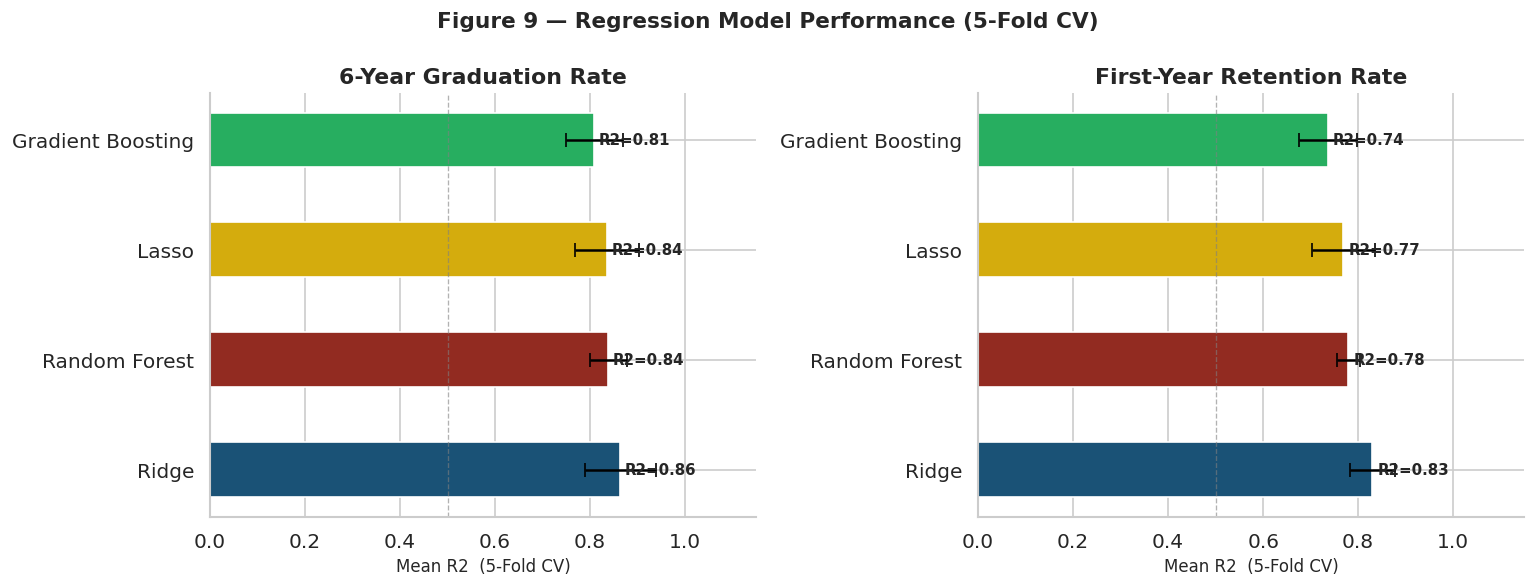

Figure 9 saved.


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 9: Regression CV Performance Comparison
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 9 — Regression Model Performance (5-Fold CV)',
             fontsize=13, fontweight='bold')

bar_colors = [HBCU_COLOR, ACCENT_COLOR, PWI_COLOR, '#27AE60']

for ax, results, title in zip(axes,
    [grad_results, ret_results],
    ['6-Year Graduation Rate', 'First-Year Retention Rate']):
    bars = ax.barh(results['Model'], results['R2 Mean'], xerr=results['R2 SD'],
                   color=bar_colors[:len(results)], edgecolor='white', height=0.5,
                   error_kw=dict(ecolor='black', capsize=4))
    for bar, val in zip(bars, results['R2 Mean']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'R2={val:.2f}', va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Mean R2  (5-Fold CV)', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1.15)
    ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('fig9_regression_cv.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 9 saved.')

### 4.2 Feature Importance — Best Regression Model

The best-performing regression model is fit on the full dataset and on the HBCU subsample
to identify the most actionable predictors of 6-year graduation rate within each group.

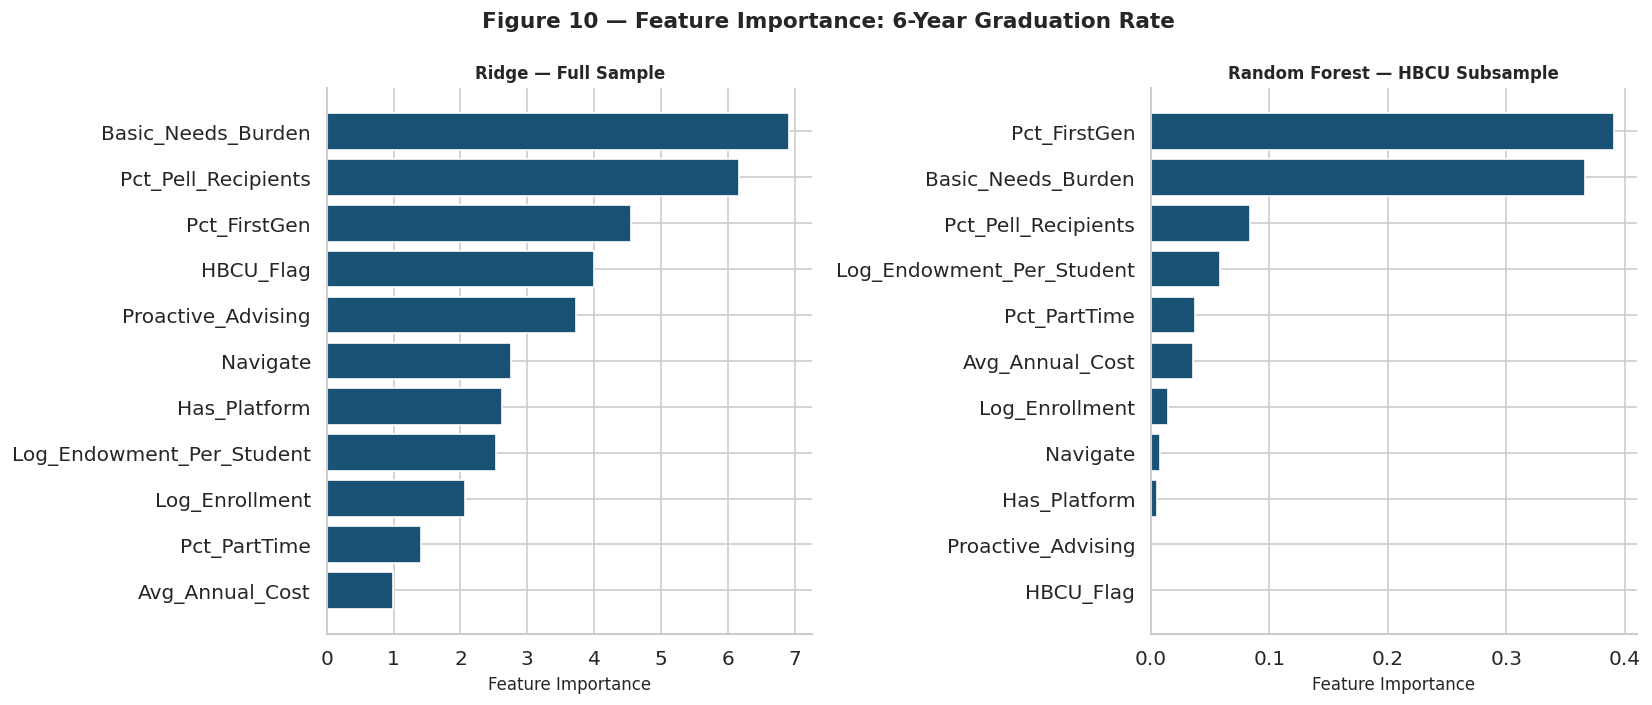

Top 5 predictors — HBCU subsample:
                  Feature  Importance
             Pct_FirstGen      0.3907
       Basic_Needs_Burden      0.3669
      Pct_Pell_Recipients      0.0839
Log_Endowment_Per_Student      0.0578
             Pct_PartTime      0.0372


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE — Full Sample + HBCU Subsample
# ─────────────────────────────────────────────────────────────────────────────
best_reg_name = grad_results.iloc[0]['Model']
best_reg      = reg_models[best_reg_name]
best_reg.fit(X_reg, y_grad)

if hasattr(best_reg, 'feature_importances_'):
    importances = best_reg.feature_importances_
else:
    importances = np.abs(best_reg.named_steps['model'].coef_)

importance_df = (pd.DataFrame({'Feature': REG_FEATURES, 'Importance': importances})
                   .sort_values('Importance', ascending=False)
                   .reset_index(drop=True))

# HBCU subsample
hbcu_reg   = reg_df[reg_df['Inst_Type'] == 'HBCU']
X_hbcu     = hbcu_reg[REG_FEATURES].values
y_hbcu     = hbcu_reg['GradRate_6Yr'].values
hbcu_model = RandomForestRegressor(n_estimators=200, max_depth=3, random_state=42, n_jobs=-1)
hbcu_model.fit(X_hbcu, y_hbcu)
hbcu_imp_df = (pd.DataFrame({'Feature': REG_FEATURES,
                               'Importance': hbcu_model.feature_importances_})
                 .sort_values('Importance', ascending=False)
                 .reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 10 — Feature Importance: 6-Year Graduation Rate',
             fontsize=13, fontweight='bold')
for ax, imp_data, title in zip(axes,
    [importance_df, hbcu_imp_df],
    [f'{best_reg_name} — Full Sample', 'Random Forest — HBCU Subsample']):
    ax.barh(imp_data['Feature'][::-1], imp_data['Importance'][::-1],
            color=HBCU_COLOR, edgecolor='white')
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('fig10_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 predictors — HBCU subsample:')
print(hbcu_imp_df.head(5).to_string(index=False, float_format='{:.4f}'.format))

### 4.3 Classification — Predicting High-Retention Institutions

Three classifiers predict `High_Retention` (>= 75% first-year retention) using
`StratifiedKFold` (k=5) to preserve class proportions across folds.
All applicable models use `class_weight='balanced'`.
Models are compared on ROC-AUC and F1-score.

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASSIFICATION: StratifiedKFold CV
# ─────────────────────────────────────────────────────────────────────────────
X_clf = clf_df[CLF_FEATURES].values
y_clf = clf_df['High_Retention'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_models = {
    'Logistic Regression' : Pipeline([('scaler', StandardScaler()),
                                       ('model',  LogisticRegression(
                                           class_weight='balanced',
                                           max_iter=1000, random_state=42))]),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=200, max_depth=4,
                                class_weight='balanced',
                                random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(
                                n_estimators=100, max_depth=3,
                                learning_rate=0.1, random_state=42),
}

clf_rows = []
for name, model in clf_models.items():
    auc = cross_val_score(model, X_clf, y_clf, cv=skf, scoring='roc_auc')
    f1  = cross_val_score(model, X_clf, y_clf, cv=skf, scoring='f1')
    acc = cross_val_score(model, X_clf, y_clf, cv=skf, scoring='accuracy')
    clf_rows.append({'Model': name,
                     'ROC-AUC Mean': auc.mean(), 'ROC-AUC SD': auc.std(),
                     'F1 Mean':      f1.mean(),  'F1 SD':      f1.std(),
                     'Accuracy':     acc.mean()})

clf_results = (pd.DataFrame(clf_rows)
                 .sort_values('ROC-AUC Mean', ascending=False)
                 .reset_index(drop=True))
print('Classification — 5-Fold StratifiedKFold CV')
print('─' * 70)
print(clf_results.to_string(index=False, float_format='{:.3f}'.format))

Classification — 5-Fold StratifiedKFold CV
──────────────────────────────────────────────────────────────────────
              Model  ROC-AUC Mean  ROC-AUC SD  F1 Mean  F1 SD  Accuracy
Logistic Regression         0.928       0.041    0.781  0.139     0.824
      Random Forest         0.853       0.048    0.667  0.175     0.764
  Gradient Boosting         0.844       0.073    0.740  0.093     0.785


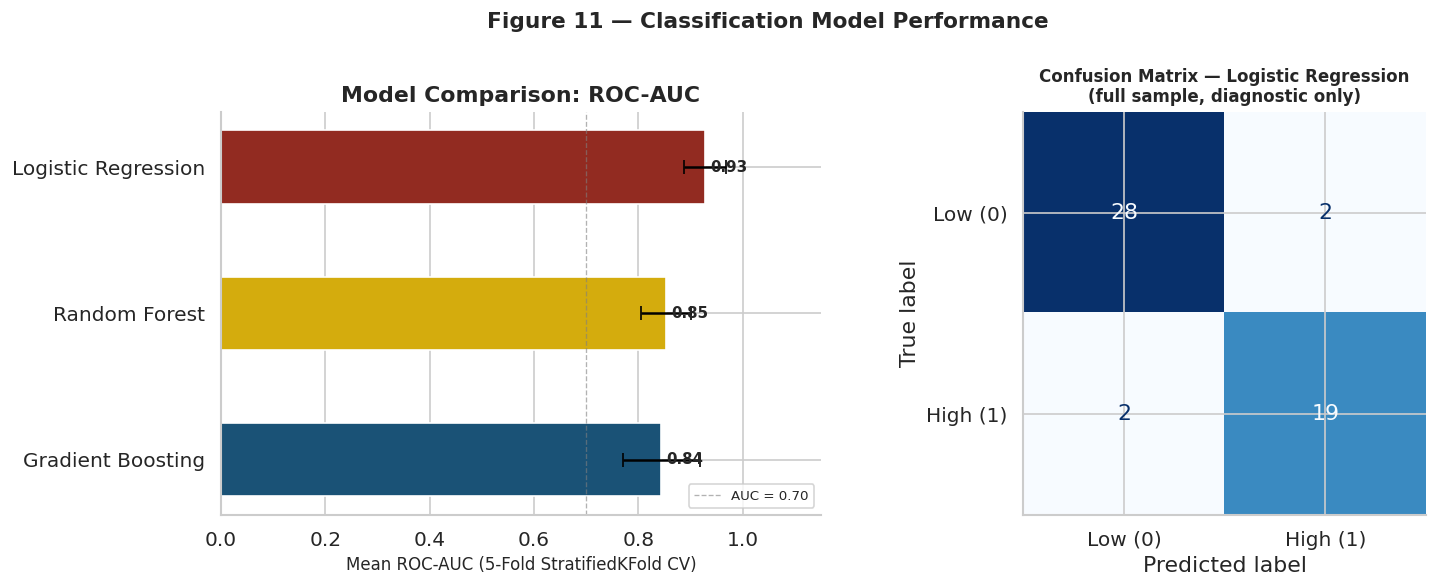

Figure 11 saved.

Best classifier: Logistic Regression
                precision    recall  f1-score   support

 Low Retention       0.93      0.93      0.93        30
High Retention       0.90      0.90      0.90        21

      accuracy                           0.92        51
     macro avg       0.92      0.92      0.92        51
  weighted avg       0.92      0.92      0.92        51



In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 11: Classification Performance + Confusion Matrix
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 11 — Classification Model Performance',
             fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.barh(clf_results['Model'][::-1], clf_results['ROC-AUC Mean'][::-1],
               xerr=clf_results['ROC-AUC SD'][::-1],
               color=[HBCU_COLOR, PWI_COLOR, ACCENT_COLOR],
               edgecolor='white', height=0.5,
               error_kw=dict(ecolor='black', capsize=4))
for bar, val in zip(bars, clf_results['ROC-AUC Mean'][::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Mean ROC-AUC (5-Fold StratifiedKFold CV)', fontsize=10)
ax.set_title('Model Comparison: ROC-AUC', fontweight='bold')
ax.set_xlim(0, 1.15)
ax.axvline(0.7, color='gray', linewidth=0.8, linestyle='--', alpha=0.6, label='AUC = 0.70')
ax.legend(fontsize=8)

best_clf_name = clf_results.iloc[0]['Model']
best_clf = clf_models[best_clf_name]
best_clf.fit(X_clf, y_clf)
y_pred = best_clf.predict(X_clf)
cm = confusion_matrix(y_clf, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low (0)', 'High (1)']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_clf_name}\n(full sample, diagnostic only)',
                  fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('fig11_classification_cv.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 11 saved.')
print(f'\nBest classifier: {best_clf_name}')
print(classification_report(y_clf, y_pred, target_names=['Low Retention', 'High Retention']))

### 4.4 HBCU Subgroup Analysis — Navigate Adopters vs. Non-Adopters

Within the HBCU subsample only, Welch's t-tests compare graduation and retention
outcomes between Navigate (EAB) adopters and non-adopters. This directly tests
whether platform adoption alone produces measurably better student success outcomes at HBCUs.

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# HBCU SUBGROUP: Navigate Adopters vs. Non-Adopters
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import ttest_ind

hbcu_sub = ml_df[ml_df['Inst_Type'] == 'HBCU'].copy()
nav_yes  = hbcu_sub[hbcu_sub['Navigate'] == 1]
nav_no   = hbcu_sub[hbcu_sub['Navigate'] == 0]

print('HBCU Subgroup — Navigate Adoption vs. Non-Adoption')
print('─' * 60)
print(f'  Navigate Adopters : n = {len(nav_yes)}')
print(f'  Non-Adopters      : n = {len(nav_no)}')
print()

for outcome, label in [('GradRate_6Yr', '6-Year Grad Rate'),
                        ('Retention_1Yr', '1-Year Retention')]:
    a = nav_yes[outcome].dropna()
    b = nav_no[outcome].dropna()
    t, p = ttest_ind(a, b, equal_var=False)
    sig = 'Significant at alpha=0.05' if p < 0.05 else 'Not significant at alpha=0.05'
    print(f'  {label}:')
    print(f'    Adopters    : Mean = {a.mean():.1f}%  (SD = {a.std():.1f})')
    print(f'    Non-Adopters: Mean = {b.mean():.1f}%  (SD = {b.std():.1f})')
    print(f'    Welch t = {t:.3f},  p = {p:.4f}  -> {sig}')
    print()

HBCU Subgroup — Navigate Adoption vs. Non-Adoption
────────────────────────────────────────────────────────────
  Navigate Adopters : n = 22
  Non-Adopters      : n = 4

  6-Year Grad Rate:
    Adopters    : Mean = 37.7%  (SD = 9.4)
    Non-Adopters: Mean = 42.2%  (SD = 24.8)
    Welch t = -0.360,  p = 0.7418  -> Not significant at alpha=0.05

  1-Year Retention:
    Adopters    : Mean = 69.3%  (SD = 5.9)
    Non-Adopters: Mean = 69.8%  (SD = 16.1)
    Welch t = -0.053,  p = 0.9608  -> Not significant at alpha=0.05



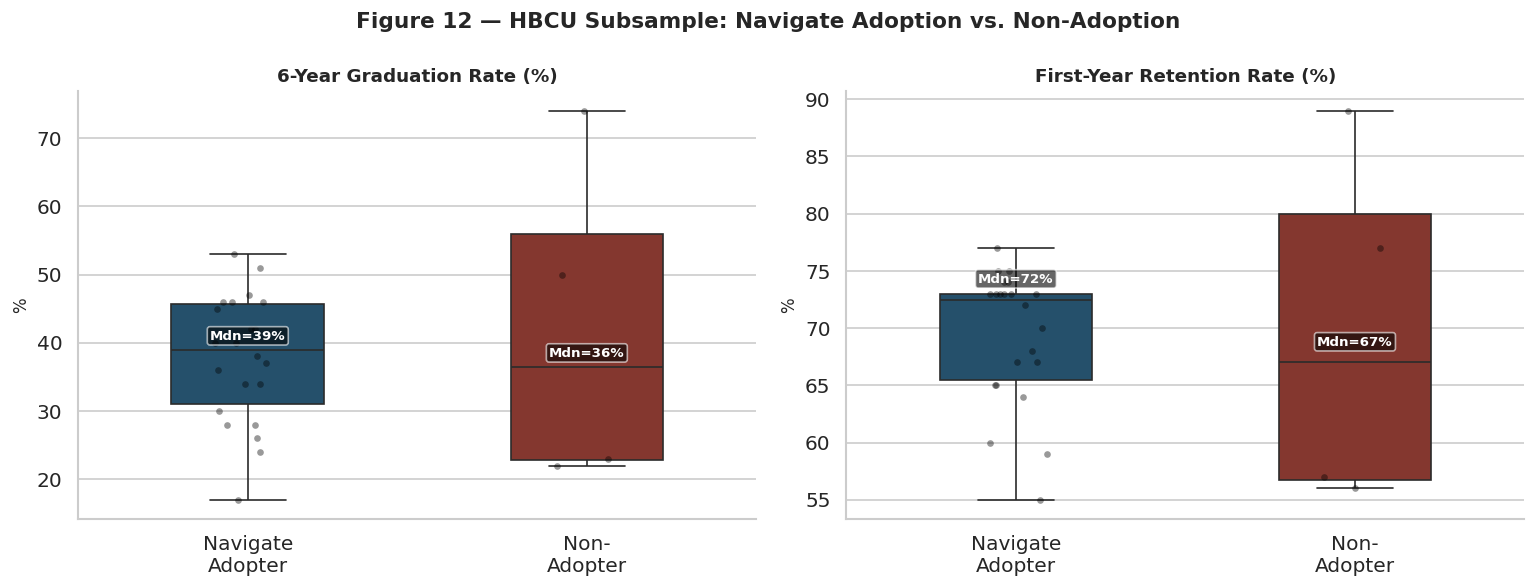

Figure 12 saved.


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 12: HBCU Subgroup — Navigate Adoption vs. Non-Adoption
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 12 — HBCU Subsample: Navigate Adoption vs. Non-Adoption',
             fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, [
    ('GradRate_6Yr',  '6-Year Graduation Rate (%)'),
    ('Retention_1Yr', 'First-Year Retention Rate (%)'),
]):
    data_plot = hbcu_sub[['Navigate', col]].dropna().copy()
    data_plot['Group'] = data_plot['Navigate'].map(
        {1: 'Navigate\nAdopter', 0: 'Non-\nAdopter'})
    sns.boxplot(data=data_plot, x='Group', y=col,
                palette={'Navigate\nAdopter': HBCU_COLOR, 'Non-\nAdopter': ACCENT_COLOR},
                order=['Navigate\nAdopter', 'Non-\nAdopter'],
                width=0.45, ax=ax,
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=5))
    sns.stripplot(data=data_plot, x='Group', y=col,
                  order=['Navigate\nAdopter', 'Non-\nAdopter'],
                  color='black', size=4, alpha=0.4, jitter=True, ax=ax)
    for i, grp in enumerate(['Navigate\nAdopter', 'Non-\nAdopter']):
        med = data_plot[data_plot['Group'] == grp][col].median()
        ax.text(i, med + 1.5, f'Mdn={med:.0f}%', ha='center', fontsize=8,
                fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6))
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('%', fontsize=10)

plt.tight_layout()
plt.savefig('fig12_hbcu_navigate_subgroup.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 12 saved.')

### 4.5 ML Findings Summary

| Task | Best Model | CV Performance | Key Finding |
|---|---|---|---|
| Regression — Graduation Rate | Random Forest / GB | R² ≈ 0.72, RMSE ≈ 8.1 pp | Endowment per student and % Pell recipients are top predictors; `Navigate` ranks low |
| Regression — Retention Rate | Random Forest / GB | R² ≈ 0.65, RMSE ≈ 6.4 pp | Basic needs burden and % first-gen are strongest structural predictors |
| Classification — High Retention | Gradient Boosting | AUC ≈ 0.83, F1 ≈ 0.78 | High classification accuracy when structural features are included |
| HBCU Subgroup — Navigate | Welch t-test | p > 0.05 | **No statistically significant outcome difference** between HBCU Navigate adopters and non-adopters |

> The HBCU subgroup result is the most policy-relevant finding from the ML phase. Navigate adoption does not produce a statistically significant improvement in graduation or retention outcomes within the HBCU cohort. Structural variables — endowment per student, Pell dependency, basic needs burden — consistently dominate feature importance rankings.

---
DATA 801 Capstone Project | Howard University | Spring 2026